# Citi Bike 2025 EDA + Modeling v7 — capacity fix

Builds on v6 by turning the GBFS capacity merge into a real **availability-target** workflow:

- **Capacity-aware targets** — the notebook now creates `utilization_ratio_next_hour` (primary target) from station capacity + cumulative net flow, so the modeling section matches the project's availability goal.
- **Leakage-safe availability features** — lagged and rolling versions of `estimated_bikes`, `available_docks`, and `utilization_ratio` are added for forecasting.
- **Prediction bounds** — availability-style predictions are clipped to valid ranges (`[0, 1]` for utilization, `[0, capacity]` for counts).
- **More robust metadata** — raw vs imputed capacity is tracked so you can clearly explain which rows support the availability proxy.


## Roadmap

1. Load the trip, weather, and station lookup files.
2. Fetch **GBFS station capacity** and merge it into station metadata.
3. Aggregate trips into a **station-hour** table.
4. Merge station metadata (with capacity flags) and hourly weather.
5. Engineer calendar, lag, rolling, cyclic, and next-hour flow features.
6. Build the **capacity / availability proxy** and next-hour utilization target.
7. Add **station clusters** (K-Means, enabled) and **weather PCA** (with scree plot).
8. Run EDA — including capacity distribution and utilization plots.
9. Compare models on **validation**, retrain on **train + validation**, and evaluate once on **test**.
10. Produce report-ready diagnostics for the selected primary target.


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print("google.colab is not available in this environment — skipping Drive mount.")


Mounted at /content/drive


In [2]:
from pathlib import Path
import warnings
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.errors import EmptyDataError
from pandas.tseries.holiday import USFederalHolidayCalendar

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.cluster import KMeans as SKKMeans
from sklearn.decomposition import PCA as SKPCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression as SKLinearRegression
from sklearn.ensemble import RandomForestRegressor as SKRandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    if not Path("rapidsai-csp-utils").exists():
        !git clone https://github.com/rapidsai/rapidsai-csp-utils.git
    !python rapidsai-csp-utils/colab/pip-install.py
else:
    print("Not running in Colab — skipping the RAPIDS Colab installer cell.")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)


Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (200/200), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 634 (delta 152), reused 90 (delta 88), pack-reused 434 (from 3)
Receiving objects: 100% (634/634), 209.09 KiB | 10.45 MiB/s, done.
Resolving deltas: 100% (326/326), done.
Installing RAPIDS remaining 26.02 libraries
Using Python 3.12.13 environment at: /usr
Resolved 176 packages in 2.07s
Prepared 11 packages in 1.24s
Uninstalled 5 packages in 202ms
Installed 11 packages in 68ms
 - bokeh==3.8.2
 + bokeh==3.6.3
 + cugraph-cu12==26.2.0
 + cuxfilter-cu12==26.2.0
 + datashader==0.19.0
 - holoviews==1.22.1
 + holoviews==1.20.2
 + jupyter-server-proxy==4.5.0
 - nvidia-cuda-nvcc-cu12==12.5.82
 + nvidia-cuda-nvcc-cu12==12.8.93
 - panel==1.8.10
 + panel==1.7.5
 + pyct==0.6.0
 - shapely==2.1.2
 + shapely==2.0.7
 + simpervisor==1.0.0

        **********************************************************************

In [3]:
# --- Update these paths for your machine if needed ---
TRIP_CSV_PATH = Path("/content/drive/MyDrive/cleaned_combined.csv")
STATION_LOOKUP_PATH = Path("/content/station_lookup.csv")
WEATHER_CSV_PATH = Path("/content/nyc2025weatherdata.csv")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CHUNK_SIZE = 300_000
FORCE_REBUILD = True
TOP_N_STATIONS_FOR_MODEL = 150

# Primary target is now capacity-aware availability rather than pure trip flow.
# Change PRIMARY_TARGET to "departures_next_hour" (or another target below) if you want
# to reproduce the earlier flow-focused experiments.
TARGETS = [
    "utilization_ratio_next_hour",
    "departures_next_hour",
    "arrivals_next_hour",
    "net_flow_next_hour",
]
PRIMARY_TARGET = "utilization_ratio_next_hour"

USE_STATION_CLUSTERING = True
N_STATION_CLUSTERS = 8
USE_WEATHER_PCA = True
N_WEATHER_PCS = 3
RANDOM_STATE = 42

# Explicit GPU path (reliable rewrite):
# - model training uses cuML when RAPIDS is installed
# - station-hour aggregation uses cuDF when the input file fits in GPU memory
# - clustering / PCA can also use the GPU
USE_GPU_MODELS = True
USE_GPU_AGGREGATION = True
USE_GPU_CLUSTERING = True
USE_GPU_WEATHER_PCA = True
GPU_NUMERIC_DTYPE = np.float32

# GBFS capacity feed — live station metadata from CitiBike
# NOTE: This is a real-time feed; capacity values reflect today's station config.
# Historical capacity changes are not available via GBFS — acknowledge this in the report.
GBFS_STATION_INFO_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json"


In [4]:
def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, dtype=np.float32)


GPU_CONTEXT = {
    "enabled": False,
    "device_count": 0,
    "reason": "RAPIDS imports not attempted.",
    "cp": None,
    "cudf": None,
    "GPULinearRegression": None,
    "GPURandomForestRegressor": None,
    "GPUKMeans": None,
    "GPUPCA": None,
}

try:
    import cupy as cp
    import cudf
    from cuml.cluster import KMeans as GPUKMeans
    from cuml.decomposition import PCA as GPUPCA
    from cuml.ensemble import RandomForestRegressor as GPURandomForestRegressor
    from cuml.linear_model import LinearRegression as GPULinearRegression

    device_count = int(cp.cuda.runtime.getDeviceCount())
    GPU_CONTEXT.update({
        "enabled": device_count > 0,
        "device_count": device_count,
        "reason": "RAPIDS imports succeeded.",
        "cp": cp,
        "cudf": cudf,
        "GPULinearRegression": GPULinearRegression,
        "GPURandomForestRegressor": GPURandomForestRegressor,
        "GPUKMeans": GPUKMeans,
        "GPUPCA": GPUPCA,
    })
except Exception as exc:
    GPU_CONTEXT["reason"] = f"RAPIDS imports unavailable: {exc}"

print("GPU acceleration available:", GPU_CONTEXT["enabled"])
print("GPU devices detected:", GPU_CONTEXT["device_count"])
print("Runtime note:", GPU_CONTEXT["reason"])
if not GPU_CONTEXT["enabled"]:
    print("Notebook will fall back to pandas/scikit-learn unless RAPIDS is installed in this Colab runtime.")


GPU acceleration available: True
GPU devices detected: 1
Runtime note: RAPIDS imports succeeded.


GBFS: fetched 2406 stations
  Active (capacity > 0): 2341
  Inactive (capacity = 0): 65
  Capacity range: 0 – 123


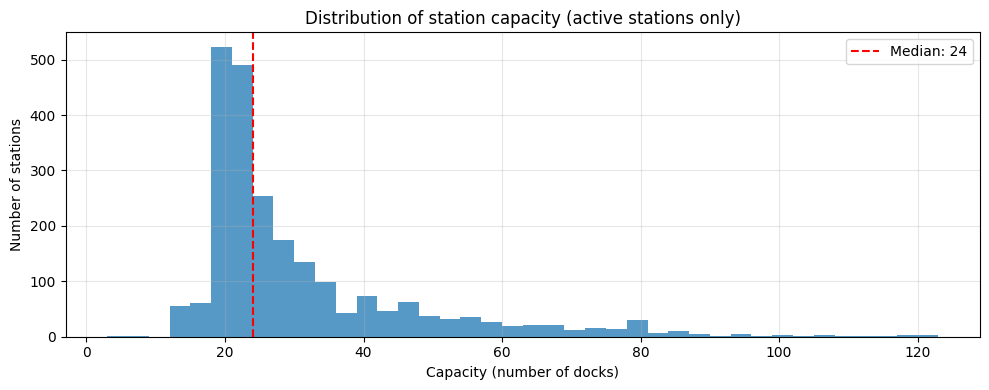

,capacity
count,2406.000000
mean,29.935578
std,17.759505
min,0.000000
25%,20.000000
50%,24.000000
75%,34.000000
max,123.000000


In [5]:
## Fetch GBFS station capacity
# The GBFS station_information feed provides current capacity (number of docks) per station.
# We merge this into the station lookup table so capacity is available as a feature.
# Stations with capacity=0 are inactive placeholders — we flag but do not drop them
# since they may still appear in historical trip data.

def fetch_gbfs_capacity(url, timeout=15):
    """Download station capacity from GBFS station_information feed."""
    try:
        resp = requests.get(url, timeout=timeout)
        resp.raise_for_status()
        data = resp.json()
        stations = data["data"]["stations"]
        cap_df = pd.DataFrame([
            {
                "station_id": str(s["station_id"]),
                "capacity": int(s.get("capacity", 0)),
                "gbfs_name": s.get("name", ""),
            }
            for s in stations
        ])
        cap_df["station_id"] = cap_df["station_id"].astype("string")
        print(f"GBFS: fetched {len(cap_df)} stations")
        print(f"  Active (capacity > 0): {(cap_df['capacity'] > 0).sum()}")
        print(f"  Inactive (capacity = 0): {(cap_df['capacity'] == 0).sum()}")
        print(f"  Capacity range: {cap_df['capacity'].min()} – {cap_df['capacity'].max()}")
        return cap_df
    except Exception as e:
        print(f"WARNING: Could not fetch GBFS capacity ({e}). Proceeding without capacity feature.")
        return pd.DataFrame(columns=["station_id", "capacity", "gbfs_name"])

gbfs_capacity = fetch_gbfs_capacity(GBFS_STATION_INFO_URL)

# Quick capacity distribution preview
if len(gbfs_capacity) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    active = gbfs_capacity[gbfs_capacity["capacity"] > 0]["capacity"]
    ax.hist(active, bins=40, edgecolor="none", alpha=0.75)
    ax.set_title("Distribution of station capacity (active stations only)")
    ax.set_xlabel("Capacity (number of docks)")
    ax.set_ylabel("Number of stations")
    ax.axvline(active.median(), color="red", linestyle="--", label=f"Median: {active.median():.0f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    display(gbfs_capacity.describe())


## Safe schema previews

In [6]:
preview = pd.read_csv(TRIP_CSV_PATH, nrows=5)
preview.columns = preview.columns.str.strip().str.lower()
trip_columns = preview.columns.tolist()

print("Trip columns:")
print(trip_columns)
display(preview.head())

if STATION_LOOKUP_PATH.exists():
    station_lookup_preview = pd.read_csv(STATION_LOOKUP_PATH, nrows=5)
    station_lookup_preview.columns = station_lookup_preview.columns.str.strip().str.lower()
    display(station_lookup_preview.head())
else:
    print("station_lookup.csv not found. The notebook will continue with a minimal station table.")

weather_preview = pd.read_csv(WEATHER_CSV_PATH, nrows=5)
weather_preview.columns = weather_preview.columns.str.strip()
display(weather_preview.head())


Trip columns:
['started_at', 'ended_at', 'start_station_id', 'end_station_id', 'start_station_name', 'end_station_name', 'rideable_type', 'member_casual']


,started_at,ended_at,start_station_id,end_station_id,start_station_name,end_station_name,rideable_type,member_casual
0,2025-01-01 14:52:26,2025-01-01 14:59:53,6182.02,5746.02,W 20 St & 7 Ave,E 10 St & 2 Ave,electric_bike,casual
1,2025-01-10 05:03:13,2025-01-10 05:13:13,6182.02,6004.07,W 20 St & 7 Ave,E 25 St & 1 Ave,classic_bike,member
2,2025-01-13 13:40:17,2025-01-13 13:47:05,5238.05,5137.11,St James Pl & Oliver St,Fulton St & William St,classic_bike,member
3,2025-01-10 08:29:16,2025-01-10 08:34:49,5238.05,5137.11,St James Pl & Oliver St,Fulton St & William St,electric_bike,member
4,2025-01-11 18:59:48,2025-01-11 19:13:21,6197.08,5414.06,E 33 St & 1 Ave,Allen St & Rivington St,electric_bike,member


,station_id,station_name,lat,lng
0,1234.56,Morgan HCT Charging,40.708948,-73.932777
1,190 Morgan,190 Morgan,40.711072,-73.932096
2,1964.01,101 St & Fort Hamilton Pkwy,40.611240,-74.032820
3,2009.04,Shore Rd & 4 Ave,40.611500,-74.035130
4,2042.01,4 Ave & 99 St,40.613270,-74.033150


,location_id,time,temperature_2m (°F),precipitation (inch),rain (inch),snowfall (inch),snow_depth (ft),wind_speed_10m (mp/h),soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_2m (%),dew_point_2m (°F),apparent_temperature (°F),wind_gusts_10m (mp/h),wind_direction_10m (°)
0,0,2025-01-01T00:00,45.6,0.146,0.146,0.0,0.0,10.7,44.3,43.7,94,44.0,39.5,22.4,91
1,0,2025-01-01T01:00,46.8,0.035,0.035,0.0,0.0,9.3,44.6,43.7,96,45.8,41.8,23.7,92
2,0,2025-01-01T02:00,47.6,0.000,0.000,0.0,0.0,4.8,45.0,43.7,97,46.7,44.7,18.1,109
3,0,2025-01-01T03:00,48.0,0.000,0.000,0.0,0.0,5.4,45.3,43.8,99,47.7,45.1,10.1,171
4,0,2025-01-01T04:00,48.0,0.000,0.000,0.0,0.0,5.5,45.7,43.9,98,47.6,45.1,10.3,223


## Detect which station columns are available

In [7]:
def pick_station_columns(columns):
    columns = set(columns)

    if "start_station_id" in columns and "end_station_id" in columns:
        return "start_station_id", "end_station_id", "id"
    if "start_station_name" in columns and "end_station_name" in columns:
        return "start_station_name", "end_station_name", "name"

    raise ValueError(
        "Could not find usable station columns. Expected start/end station ids or names."
    )

START_KEY_COL, END_KEY_COL, KEY_MODE = pick_station_columns(trip_columns)
print("Using start key column:", START_KEY_COL)
print("Using end key column:", END_KEY_COL)
print("Key mode:", KEY_MODE)


Using start key column: start_station_id
Using end key column: end_station_id
Key mode: id


## Station lookup preparation

If `station_lookup.csv` is missing, the notebook will still run with a minimal `station_key` table.
That means the main forecasting pipeline still works, but location-based clustering will rely only on activity features.


In [8]:
def normalize_station_name(series):
    s = series.astype("string").str.lower().str.strip()

    # basic cleanup
    s = s.str.replace("&", " and ", regex=False)
    s = s.str.replace("@", " at ", regex=False)
    s = s.str.replace(r"[^a-z0-9\s]", " ", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()

    return s

def prepare_station_lookup(station_lookup_path, key_mode="id", gbfs_cap_df=None):
    if not station_lookup_path.exists():
        print("station_lookup.csv not found. Proceeding without station metadata.")
        return None

    station_lookup = pd.read_csv(station_lookup_path, dtype="string")
    station_lookup.columns = station_lookup.columns.str.strip().str.lower()

    if "station_name" not in station_lookup.columns:
        raise ValueError("station_lookup.csv must contain 'station_name' for name-based matching.")

    # keep station_key behavior compatible with your notebook
    if key_mode == "id" and "station_id" in station_lookup.columns:
        station_lookup["station_key"] = station_lookup["station_id"].astype("string").str.strip()
    elif "station_name" in station_lookup.columns:
        station_lookup["station_key"] = station_lookup["station_name"].astype("string").str.strip()
    else:
        raise ValueError("Could not create station_key from station_id or station_name.")

    station_lookup["station_name"] = station_lookup["station_name"].astype("string").str.strip()
    station_lookup["station_name_norm"] = normalize_station_name(station_lookup["station_name"])

    keep_cols = [c for c in ["station_key", "station_id", "station_name", "lat", "lng", "station_name_norm"] if c in station_lookup.columns]
    station_lookup = station_lookup[keep_cols].drop_duplicates(subset=["station_key"])

    if gbfs_cap_df is not None and len(gbfs_cap_df) > 0:
        cap_df = gbfs_cap_df.copy()
        cap_df.columns = cap_df.columns.str.strip().str.lower()

        # adjust this if your GBFS name column has a different name
        gbfs_name_col = None
        for candidate in ["gbfs_name", "station_name", "name"]:
            if candidate in cap_df.columns:
                gbfs_name_col = candidate
                break

        if gbfs_name_col is None:
            raise ValueError("GBFS capacity dataframe must contain a station name column such as 'gbfs_name'.")

        if "capacity" not in cap_df.columns:
            raise ValueError("GBFS capacity dataframe must contain 'capacity'.")

        cap_df[gbfs_name_col] = cap_df[gbfs_name_col].astype("string").str.strip()
        cap_df["station_name_norm"] = normalize_station_name(cap_df[gbfs_name_col])
        cap_df["capacity"] = pd.to_numeric(cap_df["capacity"], errors="coerce")

        cap_df = (
            cap_df.sort_values(["station_name_norm", "capacity"], ascending=[True, False])
            .drop_duplicates(subset=["station_name_norm"], keep="first")
        )

        station_lookup = station_lookup.merge(
            cap_df[[gbfs_name_col, "station_name_norm", "capacity"]].rename(columns={gbfs_name_col: "gbfs_name"}),
            on="station_name_norm",
            how="left"
        )

        station_lookup = station_lookup.rename(columns={"capacity": "capacity_raw"})
        station_lookup["capacity_known"] = station_lookup["capacity_raw"].notna().astype("int8")
        station_lookup["capacity_imputed"] = station_lookup["capacity_raw"].isna().astype("int8")
        station_lookup["is_active_station"] = station_lookup["capacity_raw"].fillna(0).gt(0).astype("int8")

        median_cap = station_lookup.loc[station_lookup["capacity_raw"] > 0, "capacity_raw"].median()
        if pd.isna(median_cap):
            median_cap = np.nan

        station_lookup["capacity"] = station_lookup["capacity_raw"]
        if not pd.isna(median_cap):
            station_lookup["capacity"] = station_lookup["capacity"].fillna(median_cap)

        matched = int(station_lookup["capacity_known"].sum())
        total = int(len(station_lookup))
        pct = 100 * matched / total if total else 0.0

        print(f"Capacity matched by NAME: {matched}/{total} stations ({pct:.1f}%)")

        if matched < total:
            print("\nUnmatched station names preview:")
            display(
                station_lookup.loc[station_lookup["capacity_known"] == 0,
                                   ["station_key", "station_name", "station_name_norm"]].head(10)
            )

    else:
        print("No GBFS capacity data available.")
        station_lookup["gbfs_name"] = pd.NA
        station_lookup["capacity_raw"] = np.nan
        station_lookup["capacity_known"] = np.int8(0)
        station_lookup["capacity_imputed"] = np.int8(1)
        station_lookup["is_active_station"] = np.int8(0)
        station_lookup["capacity"] = np.float32(0)

    return station_lookup

## Chunked station-hour aggregation

This is the heaviest preprocessing step.

For each trip chunk, we count:
- departures by `(start station, start hour)`
- arrivals by `(end station, end hour)`

Then we build a station-hour table with:
- `departures`
- `arrivals`
- `net_flow = arrivals - departures`
- `total_activity = arrivals + departures`

This version also fixes a counting bug from the starter notebook by making sure each chunk is added **once** to the running totals.


In [9]:
def save_table_with_fallback(df, preferred_path):
    preferred_path = Path(preferred_path)
    try:
        df.to_parquet(preferred_path, index=False)
        return preferred_path
    except Exception as exc:
        fallback_path = preferred_path.with_suffix(".csv")
        print(f"Parquet save failed ({exc}). Saving CSV cache instead: {fallback_path}")
        df.to_csv(fallback_path, index=False)
        return fallback_path


def load_cached_table(preferred_path):
    preferred_path = Path(preferred_path)

    if preferred_path.exists():
        try:
            return pd.read_parquet(preferred_path)
        except Exception as exc:
            print(f"Failed to read parquet cache {preferred_path}: {exc}")

    csv_fallback = preferred_path.with_suffix(".csv")
    if csv_fallback.exists():
        try:
            print(f"Loading cached table from {csv_fallback}")
            return pd.read_csv(csv_fallback, parse_dates=["hour"])
        except EmptyDataError:
            print(f"CSV cache is empty: {csv_fallback}")
            return None
        except Exception as exc:
            print(f"Failed to read CSV fallback {csv_fallback}: {exc}")
            return None

    return None


def aggregate_station_hour_cpu(
    trip_csv_path,
    trip_columns,
    start_key_col,
    end_key_col,
    chunksize=300_000,
    cache_path=None,
    force_rebuild=False,
):
    if cache_path is not None and not force_rebuild:
        cached = load_cached_table(cache_path)
        if cached is not None:
            return cached

    base_usecols = ["started_at", "ended_at", start_key_col, end_key_col]
    usecols = [c for c in base_usecols if c in trip_columns]
    dtype_map = {start_key_col: "string", end_key_col: "string"}

    departures = pd.Series(dtype="float64")
    arrivals = pd.Series(dtype="float64")

    reader = pd.read_csv(
        trip_csv_path,
        usecols=usecols,
        dtype=dtype_map,
        chunksize=chunksize,
        low_memory=True,
    )

    for chunk_idx, chunk in enumerate(reader, start=1):
        chunk.columns = chunk.columns.str.strip().str.lower()
        chunk = chunk.dropna(subset=["started_at", "ended_at", start_key_col, end_key_col]).copy()

        chunk["started_at"] = pd.to_datetime(chunk["started_at"], errors="coerce")
        chunk["ended_at"] = pd.to_datetime(chunk["ended_at"], errors="coerce")
        chunk = chunk.dropna(subset=["started_at", "ended_at"]).copy()

        chunk[start_key_col] = chunk[start_key_col].astype("string")
        chunk[end_key_col] = chunk[end_key_col].astype("string")

        chunk["start_hour"] = chunk["started_at"].dt.floor("h")
        chunk["end_hour"] = chunk["ended_at"].dt.floor("h")

        dep = chunk.groupby([start_key_col, "start_hour"]).size().astype("float64")
        arr = chunk.groupby([end_key_col, "end_hour"]).size().astype("float64")

        departures = dep if departures.empty else departures.add(dep, fill_value=0)
        arrivals = arr if arrivals.empty else arrivals.add(arr, fill_value=0)

        if chunk_idx % 5 == 0:
            print(f"Processed {chunk_idx} CPU chunks...")

    departures = departures.rename("departures").reset_index()
    departures = departures.rename(columns={start_key_col: "station_key", "start_hour": "hour"})

    arrivals = arrivals.rename("arrivals").reset_index()
    arrivals = arrivals.rename(columns={end_key_col: "station_key", "end_hour": "hour"})

    station_hour = departures.merge(arrivals, on=["station_key", "hour"], how="outer")
    station_hour["departures"] = station_hour["departures"].fillna(0).astype("int32")
    station_hour["arrivals"] = station_hour["arrivals"].fillna(0).astype("int32")
    station_hour["station_key"] = station_hour["station_key"].astype("string")
    station_hour["hour"] = pd.to_datetime(station_hour["hour"])

    station_hour["net_flow"] = station_hour["arrivals"] - station_hour["departures"]
    station_hour["total_activity"] = station_hour["arrivals"] + station_hour["departures"]
    station_hour = station_hour.sort_values(["station_key", "hour"]).reset_index(drop=True)

    if cache_path is not None:
        saved_to = save_table_with_fallback(station_hour, cache_path)
        print(f"Saved station-hour cache to {saved_to}")

    return station_hour


def aggregate_station_hour_gpu(
    trip_csv_path,
    trip_columns,
    start_key_col,
    end_key_col,
    cache_path=None,
    force_rebuild=False,
):
    if cache_path is not None and not force_rebuild:
        cached = load_cached_table(cache_path)
        if cached is not None:
            return cached

    cudf = GPU_CONTEXT["cudf"]
    if cudf is None:
        raise RuntimeError("cuDF is not available in this runtime.")

    base_usecols = ["started_at", "ended_at", start_key_col, end_key_col]
    usecols = [c for c in base_usecols if c in trip_columns]

    # Keep station IDs as strings; let cuDF parse the datetime columns.
    dtype_map = {
        c: "str" for c in [start_key_col, end_key_col] if c in usecols
    }

    parse_date_cols = [c for c in ["started_at", "ended_at"] if c in usecols]

    print("Attempting single-pass GPU station-hour aggregation...")
    gdf = cudf.read_csv(
        trip_csv_path,
        usecols=usecols,
        dtype=dtype_map,
        parse_dates=parse_date_cols,
    )

    gdf.columns = [str(c).strip().lower() for c in gdf.columns]
    gdf = gdf.dropna(subset=["started_at", "ended_at", start_key_col, end_key_col])

    gdf[start_key_col] = gdf[start_key_col].astype("str")
    gdf[end_key_col] = gdf[end_key_col].astype("str")

    gdf["start_hour"] = gdf["started_at"].dt.floor("H")
    gdf["end_hour"] = gdf["ended_at"].dt.floor("H")

    dep = gdf.groupby([start_key_col, "start_hour"]).size().reset_index()
    dep.columns = ["station_key", "hour", "departures"]

    arr = gdf.groupby([end_key_col, "end_hour"]).size().reset_index()
    arr.columns = ["station_key", "hour", "arrivals"]

    station_hour = dep.merge(arr, on=["station_key", "hour"], how="outer")
    station_hour["departures"] = station_hour["departures"].fillna(0).astype("int32")
    station_hour["arrivals"] = station_hour["arrivals"].fillna(0).astype("int32")
    station_hour["net_flow"] = station_hour["arrivals"] - station_hour["departures"]
    station_hour["total_activity"] = station_hour["arrivals"] + station_hour["departures"]

    station_hour = station_hour.sort_values(["station_key", "hour"])
    station_hour = station_hour.to_pandas()
    station_hour["station_key"] = station_hour["station_key"].astype("string")
    station_hour["hour"] = pd.to_datetime(station_hour["hour"])
    station_hour = station_hour.reset_index(drop=True)

    if cache_path is not None:
        saved_to = save_table_with_fallback(station_hour, cache_path)
        print(f"Saved station-hour cache to {saved_to}")

    return station_hour

def aggregate_station_hour(
    trip_csv_path,
    trip_columns,
    start_key_col,
    end_key_col,
    chunksize=300_000,
    cache_path=None,
    force_rebuild=False,
):
    if USE_GPU_AGGREGATION and GPU_CONTEXT["enabled"]:
        try:
            return aggregate_station_hour_gpu(
                trip_csv_path=trip_csv_path,
                trip_columns=trip_columns,
                start_key_col=start_key_col,
                end_key_col=end_key_col,
                cache_path=cache_path,
                force_rebuild=force_rebuild,
            )
        except Exception as exc:
            print(f"GPU aggregation failed ({exc}). Falling back to pandas chunked aggregation.")

    return aggregate_station_hour_cpu(
        trip_csv_path=trip_csv_path,
        trip_columns=trip_columns,
        start_key_col=start_key_col,
        end_key_col=end_key_col,
        chunksize=chunksize,
        cache_path=cache_path,
        force_rebuild=force_rebuild,
    )


In [10]:
station_hour_cache = OUTPUT_DIR / "station_hour_2025_v2.parquet"
station_hour = aggregate_station_hour(
    trip_csv_path=TRIP_CSV_PATH,
    trip_columns=trip_columns,
    start_key_col=START_KEY_COL,
    end_key_col=END_KEY_COL,
    chunksize=CHUNK_SIZE,
    cache_path=station_hour_cache,
    force_rebuild=FORCE_REBUILD,
)

station_lookup = prepare_station_lookup(STATION_LOOKUP_PATH, gbfs_cap_df=gbfs_capacity)
if station_lookup is None:
    station_lookup = pd.DataFrame({"station_key": station_hour["station_key"].drop_duplicates().astype("string")})

print(station_hour.shape)
print("Unique stations:", station_hour["station_key"].nunique())
print("Hour range:", station_hour["hour"].min(), "to", station_hour["hour"].max())
print("Total departures:", int(station_hour["departures"].sum()))
print("Total arrivals:", int(station_hour["arrivals"].sum()))
display(station_hour.head())


Attempting single-pass GPU station-hour aggregation...
Saved station-hour cache to outputs/station_hour_2025_v2.parquet
Capacity matched by NAME: 2381/2428 stations (98.1%)

Unmatched station names preview:


,station_key,station_name,station_name_norm
0,1234.56,Morgan HCT Charging,morgan hct charging
1,190 Morgan,190 Morgan,190 morgan
98,3138.09,58 St & 2 Ave,58 st and 2 ave
186,3460.06,2 Ave & 37 St,2 ave and 37 st
336,4033.16,Sterling Pl & Franklin Ave,sterling pl and franklin ave
352,4077.07,Court St & Nelson St,court st and nelson st
413,4199.13,Carlton Ave & St Marks Ave,carlton ave and st marks ave
525,4488.08,Court St & State St,court st and state st
581,4645.09,Hicks St & Montague St,hicks st and montague st
640,4801.04,Melrose St & Broadway,melrose st and broadway


(11966828, 6)
Unique stations: 2428
Hour range: 2024-12-31 12:00:00 to 2025-12-31 23:00:00
Total departures: 45623754
Total arrivals: 45623754


,station_key,hour,departures,arrivals,net_flow,total_activity
0,1234.56,2025-06-18 22:00:00,0,1,1,1
1,1234.56,2025-06-18 23:00:00,1,1,0,2
2,1234.56,2025-06-19 23:00:00,1,0,-1,1
3,1234.56,2025-06-20 09:00:00,1,1,0,2
4,1234.56,2025-06-20 12:00:00,1,1,0,2


In [11]:
lookup_debug = pd.read_csv(STATION_LOOKUP_PATH, dtype={"station_id": "string"})
lookup_debug.columns = lookup_debug.columns.str.strip().str.lower()
lookup_debug["station_id"] = lookup_debug["station_id"].astype("string").str.strip()

gbfs_debug = gbfs_capacity.copy()
gbfs_debug["station_id"] = gbfs_debug["station_id"].astype("string").str.strip()

print("lookup station_id sample:")
display(lookup_debug["station_id"].head(20))

print("gbfs station_id sample:")
display(gbfs_debug["station_id"].head(20))

print("direct exact overlap:", lookup_debug["station_id"].isin(gbfs_debug["station_id"]).sum())

lookup station_id sample:


,station_id
0,1234.56
1,190 Morgan
2,1964.01
3,2009.04
4,2042.01
5,2086.07
6,2118.13
7,2127.03
8,2158.08
9,2190.08


gbfs station_id sample:


,station_id
0,807e9f5a-49b6-4b7e-847b-4a60cff330ed
1,66dc292c-0aca-11e7-82f6-3863bb44ef7c
2,2206778196198800034
3,41495491-5d89-4e14-aab9-c3db04aad399
4,1905837242740508940
5,2177016530523622712
6,2177016940364559212
7,06439006-11b6-44f0-8545-c9d39035f32a
8,2206772051528680770
9,2206771530409556572


direct exact overlap: 0


In [12]:
display(lookup_debug.head(10))
display(gbfs_debug.head(10))
print("direct exact overlap:", lookup_debug["station_id"].isin(gbfs_debug["station_id"]).sum())

,station_id,station_name,lat,lng
0,1234.56,Morgan HCT Charging,40.708948,-73.932777
1,190 Morgan,190 Morgan,40.711072,-73.932096
2,1964.01,101 St & Fort Hamilton Pkwy,40.611240,-74.032820
3,2009.04,Shore Rd & 4 Ave,40.611500,-74.035130
4,2042.01,4 Ave & 99 St,40.613270,-74.033150
5,2086.07,99 St & 3 Ave,40.614510,-74.035020
6,2118.13,Fort Hamilton Pkwy & 95 St,40.614660,-74.029460
7,2127.03,Shore Rd & 97 St,40.615290,-74.037790
8,2158.08,4 Ave & 94 St,40.616890,-74.030910
9,2190.08,Fort Hamilton Pkwy & 92 St,40.617170,-74.027440


,station_id,capacity,gbfs_name
0,807e9f5a-49b6-4b7e-847b-4a60cff330ed,18,Linden St & Knickerbocker Ave
1,66dc292c-0aca-11e7-82f6-3863bb44ef7c,55,Broadway & W 41 St
2,2206778196198800034,0,Yellowstone Blvd & 68 Ave
3,41495491-5d89-4e14-aab9-c3db04aad399,19,43 St & Skillman Ave
4,1905837242740508940,35,31 St & Broadway
5,2177016530523622712,0,Post Rd & W 251 St
6,2177016940364559212,0,David Sheridan Plaza & Broadway
7,06439006-11b6-44f0-8545-c9d39035f32a,78,Vesey St & Church St
8,2206772051528680770,0,62 Dr & 110 St
9,2206771530409556572,0,63 Ave & 99 St


direct exact overlap: 0


## Merge station metadata and hourly weather

In [13]:
def load_weather(weather_csv_path):
    weather = pd.read_csv(weather_csv_path)

    rename_map = {
        "time": "hour",
        "temperature_2m (degF)": "temperature_f",
        "temperature_2m (°F)": "temperature_f",
        "precipitation (inch)": "precipitation_in",
        "rain (inch)": "rain_in",
        "snowfall (inch)": "snowfall_in",
        "snow_depth (ft)": "snow_depth_ft",
        "wind_speed_10m (mp/h)": "wind_speed_mph",
        "relative_humidity_2m (%)": "relative_humidity_pct",
        "dew_point_2m (degF)": "dew_point_f",
        "dew_point_2m (°F)": "dew_point_f",
        "apparent_temperature (degF)": "apparent_temperature_f",
        "apparent_temperature (°F)": "apparent_temperature_f",
        "wind_gusts_10m (mp/h)": "wind_gusts_mph",
        "wind_direction_10m (deg)": "wind_direction_deg",
        "wind_direction_10m (°)": "wind_direction_deg",
        "cloud_cover (%)": "cloud_cover_pct",
        "surface_pressure (hPa)": "surface_pressure_hpa",
        "visibility (ft)": "visibility_ft",
    }

    weather = weather.rename(columns=rename_map)
    weather.columns = [c.strip() for c in weather.columns]

    if "hour" not in weather.columns:
        raise ValueError("Could not find a time/hour column in the weather CSV.")

    weather["hour"] = pd.to_datetime(weather["hour"], errors="coerce")
    weather = weather.dropna(subset=["hour"]).copy()
    weather = weather.sort_values("hour").drop_duplicates(subset=["hour"])
    return weather


weather = load_weather(WEATHER_CSV_PATH)
station_hour_enriched = station_hour.merge(station_lookup, on="station_key", how="left")
station_hour_weather = station_hour_enriched.merge(weather, on="hour", how="left")

merged_cache = OUTPUT_DIR / "station_hour_weather_2025_v2.parquet"
save_table_with_fallback(station_hour_weather, merged_cache)

print(station_hour_weather.shape)
display(station_hour_weather.head())


(11966828, 31)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_id,station_name,lat,lng,station_name_norm,gbfs_name,capacity_raw,capacity_known,capacity_imputed,is_active_station,capacity,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg
0,1234.56,2025-06-18 22:00:00,0,1,1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0
1,1234.56,2025-06-18 23:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0
3,1234.56,2025-06-20 09:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,72.6,0.000,0.000,0.0,0.0,11.3,71.7,71.2,55.0,55.5,69.6,26.8,284.0
4,1234.56,2025-06-20 12:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,2.0,79.3,0.000,0.000,0.0,0.0,11.2,78.9,72.3,46.0,56.8,79.9,27.7,286.0


## Feature engineering

This section adds:
- calendar features,
- **cyclic (sin/cos) encoding** for `hour_of_day` and `day_of_week`,
- holiday and commute flags,
- lag and rolling features by station,
- next-hour flow targets,
- simple precipitation / snow indicators.

The next section extends this with a **capacity-based availability proxy** and next-hour utilization target.

**Note on raw current-hour counts:** `departures`, `arrivals`, `net_flow`, and `total_activity`
are excluded from the model feature set. Only their lag and rolling versions are used,
which keeps the inference setup unambiguous — at prediction time the current hour is not yet complete.


In [14]:
def engineer_features(df):
    # Convert station_key to category FIRST — makes all groupby operations much faster
    df = df.copy()
    df["station_key"] = df["station_key"].astype("category")
    df = df.sort_values(["station_key", "hour"]).reset_index(drop=True)

    df["hour_of_day"] = df["hour"].dt.hour
    df["day_of_week"] = df["hour"].dt.dayofweek
    df["month"] = df["hour"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype("int8")
    df["is_rush_hour"] = df["hour_of_day"].isin([7, 8, 9, 16, 17, 18]).astype("int8")
    df["is_commute_peak"] = ((df["is_weekend"] == 0) & (df["is_rush_hour"] == 1)).astype("int8")
    df["is_overnight"] = df["hour_of_day"].isin([0, 1, 2, 3, 4, 5]).astype("int8")

    # Cyclic encoding — prevents the model from treating hour 23 as "far" from hour 0
    df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)

    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df["hour"].min().normalize(), end=df["hour"].max().normalize())
    df["is_holiday"] = df["hour"].dt.normalize().isin(holidays).astype("int8")

    if "precipitation_in" in df.columns:
        df["is_precipitating"] = (df["precipitation_in"].fillna(0) > 0).astype("int8")
        df["heavy_precip_flag"] = (df["precipitation_in"].fillna(0) >= 0.10).astype("int8")
    else:
        df["is_precipitating"] = np.int8(0)
        df["heavy_precip_flag"] = np.int8(0)

    if "rain_in" in df.columns:
        df["is_raining"] = (df["rain_in"].fillna(0) > 0).astype("int8")
    else:
        df["is_raining"] = np.int8(0)

    if "snowfall_in" in df.columns:
        df["is_snowing"] = (df["snowfall_in"].fillna(0) > 0).astype("int8")
    else:
        df["is_snowing"] = np.int8(0)

    # ── Fast vectorized lag/rolling ───────────────────────────────────────────
    # Using category dtype + explicit shift+rolling avoids slow lambda transforms.
    # Shift is applied BEFORE rolling so no future data leaks into the window.
    base_cols = ["departures", "arrivals", "net_flow", "total_activity"]
    grp = df.groupby("station_key", observed=True, sort=False)

    for col in base_cols:
        s = grp[col]
        df[f"{col}_lag_1"]  = s.shift(1)
        df[f"{col}_lag_2"]  = s.shift(2)
        df[f"{col}_lag_24"] = s.shift(24)

        # Rolling on the already-shifted series — avoids lambda overhead
        shifted = s.shift(1)
        df[f"{col}_roll_3"]  = shifted.groupby(df["station_key"], observed=True).transform(
            lambda x: x.rolling(3,  min_periods=1).mean()
        )
        df[f"{col}_roll_24"] = shifted.groupby(df["station_key"], observed=True).transform(
            lambda x: x.rolling(24, min_periods=1).mean()
        )

    df["departures_next_hour"] = grp["departures"].shift(-1)
    df["arrivals_next_hour"]   = grp["arrivals"].shift(-1)
    df["net_flow_next_hour"]   = grp["net_flow"].shift(-1)

    return df


# ── Cache gate — only run engineer_features if the parquet cache is missing ──
feature_cache = OUTPUT_DIR / "feature_df_model_ready_2025_v7.parquet"
if feature_cache.exists():
    feature_cache.unlink()
    print("Deleted old feature cache")

if not FORCE_REBUILD and feature_cache.exists():
    print("Loading feature_df from cache...")
    feature_df = pd.read_parquet(feature_cache)
    feature_df["station_key"] = feature_df["station_key"].astype("category")
    print(f"Loaded: {feature_df.shape}")
else:
    print("Building feature_df (this runs once, then caches)...")
    feature_df = engineer_features(station_hour_weather)
    save_table_with_fallback(feature_df, feature_cache)
    print(f"Done: {feature_df.shape}")

display(feature_df.head())


Building feature_df (this runs once, then caches)...
Done: (11966828, 70)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_id,station_name,lat,lng,station_name_norm,gbfs_name,capacity_raw,capacity_known,capacity_imputed,is_active_station,capacity,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour
0,1234.56,2025-06-18 22:00:00,0,1,1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0,22,2,6,0,0,0,0,-5.000000e-01,0.866025,0.974928,-0.222521,0,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0
1,1234.56,2025-06-18 23:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0,23,2,6,0,0,0,0,-2.588190e-01,0.965926,0.974928,-0.222521,0,1,0,1,0,0.0,NaN,NaN,0.000000,0.000000,1.0,NaN,NaN,1.000000,1.000000,1.0,NaN,NaN,1.000000,1.0,1.0,NaN,NaN,1.000000,1.000000,1.0,0.0,-1.0
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0,23,3,6,0,0,0,0,-2.588190e-01,0.965926,0.433884,-0.900969,1,0,0,0,0,1.0,0.0,NaN,0.500000,0.500000,1.0,1.0,NaN,1.000000,1.000000,0.0,1.0,NaN,0.500000,0.5,2.0,1.0,NaN,1.500000,1.500000,1.0,1.0,0.0
3,1234.56,2025-06-20 09:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,72.6,0.000,0.000,0.0,0.0,11.3,71.7,71.2,55.0,55.5,69.6,26.8,284.0,9,4,6,0,1,1,0,7.071068e-01,-0.707107,-0.433884,-0.900969,0,0,0,0,0,1.0,1.0,NaN,0.666667,0.666667,0.0,1.0,NaN,0.666667,0.666667,-1.0,0.0,NaN,0.000000,0.0,1.0,2.0,NaN,1.333333,1.333333,1.0,1.0,0.0
4,1234.56,2025-06-20 12:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,2.0,79.3,0.000,0.000,0.0,0.0,11.2,78.9,72.3,46.0,56.8,79.9,27.7,286.0,12,4,6,0,0,0,0,1.224647e-16,-1.000000,-0.433884,-0.900969,0,0,0,0,0,1.0,1.0,NaN,1.000000,0.750000,1.0,0.0,NaN,0.666667,0.750000,0.0,-1.0,NaN,-0.333333,0.0,2.0,1.0,NaN,1.666667,1.500000,1.0,1.0,0.0


## Capacity / availability proxy

Using GBFS capacity + cumulative net flow, we estimate how many bikes are present at each station each hour.
That produces a bounded **availability-style target** that is closer to the original project goal than raw trip counts alone.

**Assumptions used here:**
- the day starts at **50% of capacity** for each station with known active capacity,
- cumulative net flow shifts that estimate up or down within the day,
- values are clipped to `[0, capacity]`,
- rows without known active capacity keep the proxy targets as missing rather than inventing fake availability labels.


In [15]:
print("station_lookup coverage")
display(station_lookup[["capacity_raw", "capacity_known", "capacity"]].describe())

print("\nfeature_df capacity preview")
display(feature_df[["station_key", "capacity_raw", "capacity_known", "capacity"]].head(10))

print("\nfeature_df capacity_known counts")
print(feature_df["capacity_known"].value_counts(dropna=False))

print("\nfeature_df non-null rates")
print(feature_df[["capacity_raw", "capacity"]].notna().mean())

station_lookup coverage


,capacity_raw,capacity_known,capacity
count,2381.000000,2428.000000,2428.000000
mean,31.186056,0.980643,31.046952
std,17.468995,0.137806,17.327342
min,0.000000,0.000000,0.000000
25%,20.000000,1.000000,20.000000
50%,24.000000,1.000000,24.000000
75%,35.000000,1.000000,35.000000
max,123.000000,1.000000,123.000000



feature_df capacity preview


,station_key,capacity_raw,capacity_known,capacity
0,1234.56,NaN,0,24.0
1,1234.56,NaN,0,24.0
2,1234.56,NaN,0,24.0
3,1234.56,NaN,0,24.0
4,1234.56,NaN,0,24.0
5,1234.56,NaN,0,24.0
6,1234.56,NaN,0,24.0
7,1234.56,NaN,0,24.0
8,1234.56,NaN,0,24.0
9,1234.56,NaN,0,24.0



feature_df capacity_known counts
capacity_known
1    11829473
0      137355
Name: count, dtype: int64

feature_df non-null rates
capacity_raw    0.988522
capacity        1.000000
dtype: float64


In [16]:
tmp = feature_df.copy().sort_values(["station_key", "hour"]).reset_index(drop=True)

raw_cap = pd.to_numeric(tmp.get("capacity_raw"), errors="coerce")
cap_fallback = pd.to_numeric(tmp.get("capacity"), errors="coerce")
raw_cap = raw_cap.fillna(cap_fallback)

net_flow_num = pd.to_numeric(tmp["net_flow"], errors="coerce")
daily_cum_net_flow = net_flow_num.groupby(
    [tmp["station_key"], tmp["hour"].dt.normalize()],
    observed=True
).cumsum()

active_cap = raw_cap.where(raw_cap > 0)

print("capacity_raw non-null:", raw_cap.notna().mean())
print("active_cap non-null:", active_cap.notna().mean())
print("net_flow non-null:", net_flow_num.notna().mean())
print("daily_cum_net_flow non-null:", daily_cum_net_flow.notna().mean())
print("joint usable rows:", (active_cap.notna() & daily_cum_net_flow.notna()).mean())

display(
    tmp[["station_key", "hour", "net_flow", "capacity_raw", "capacity_known", "capacity"]]
    .sample(10, random_state=42)
)



capacity_raw non-null: 1.0
active_cap non-null: 0.9990384252201168
net_flow non-null: 1.0
daily_cum_net_flow non-null: 1.0
joint usable rows: 0.9990384252201168


,station_key,hour,net_flow,capacity_raw,capacity_known,capacity
2553401,4587.02,2025-12-01 18:00:00,0,31.0,1,31.0
7008618,6323.11,2025-10-10 21:00:00,0,25.0,1,25.0
11768807,8619.02,2025-09-30 08:00:00,0,18.0,1,18.0
8278111,6762.02,2025-07-11 05:00:00,0,49.0,1,49.0
11333113,8284.01,2025-10-16 19:00:00,-1,19.0,1,19.0
6298948,6115.06,2025-11-20 14:00:00,3,42.0,1,42.0
9379052,7284.01,2025-10-21 16:00:00,2,24.0,1,24.0
337257,3315.05,2025-02-18 08:00:00,1,23.0,1,23.0
1829344,4255.05,2025-09-28 18:00:00,5,27.0,1,27.0
1187825,3993.03,2025-04-19 00:00:00,-4,25.0,1,25.0


In [17]:
def add_capacity_utilization(df):
    """
    Build a leakage-safe availability proxy using station capacity + cumulative net flow.
    """

    if "capacity" not in df.columns and "capacity_raw" not in df.columns:
        print("No capacity columns found — skipping utilization feature.")
        return df

    if "net_flow" not in df.columns:
        print("No net_flow column found — skipping utilization feature.")
        return df

    df = df.copy()
    df = df.sort_values(["station_key", "hour"]).reset_index(drop=True)

    raw_cap = pd.to_numeric(df.get("capacity_raw"), errors="coerce")
    cap_fallback = pd.to_numeric(df.get("capacity"), errors="coerce")

    if raw_cap is None:
        raw_cap = cap_fallback
    else:
        raw_cap = raw_cap.fillna(cap_fallback)

    net_flow_num = pd.to_numeric(df["net_flow"], errors="coerce")

    active_cap = raw_cap.where(raw_cap > 0)
    has_known_active_capacity = active_cap.notna()

    if "capacity_known" not in df.columns:
        df["capacity_known"] = has_known_active_capacity.astype("int8")
    if "capacity_imputed" not in df.columns:
        df["capacity_imputed"] = (~has_known_active_capacity).astype("int8")
    if "is_active_station" not in df.columns:
        df["is_active_station"] = has_known_active_capacity.astype("int8")

    df["date"] = df["hour"].dt.normalize()

    daily_cum_net_flow = net_flow_num.groupby(
        [df["station_key"], df["date"]],
        observed=True
    ).cumsum()

    estimated_bikes = pd.Series(np.nan, index=df.index, dtype="float32")
    available_docks = pd.Series(np.nan, index=df.index, dtype="float32")
    utilization_ratio = pd.Series(np.nan, index=df.index, dtype="float32")

    valid_mask = has_known_active_capacity & daily_cum_net_flow.notna()

    print("add_capacity_utilization diagnostics")
    print("  raw_cap non-null:", f"{raw_cap.notna().mean():.1%}")
    print("  active capacity rows:", f"{has_known_active_capacity.mean():.1%}")
    print("  net_flow numeric rows:", f"{net_flow_num.notna().mean():.1%}")
    print("  usable rows:", f"{valid_mask.mean():.1%}")

    if valid_mask.any():
        init_bikes = active_cap[valid_mask] * 0.5
        est_known = (init_bikes + daily_cum_net_flow[valid_mask]).clip(
            lower=0,
            upper=active_cap[valid_mask],
        )

        estimated_bikes.loc[valid_mask] = est_known.astype("float32")
        available_docks.loc[valid_mask] = (
            active_cap[valid_mask] - est_known
        ).astype("float32")
        utilization_ratio.loc[valid_mask] = (
            est_known / active_cap[valid_mask]
        ).astype("float32")

    df["estimated_bikes"] = estimated_bikes
    df["available_docks"] = available_docks
    df["utilization_ratio"] = utilization_ratio
    df["is_nearly_empty"] = (df["utilization_ratio"] <= 0.10).fillna(False).astype("int8")
    df["is_nearly_full"] = (df["utilization_ratio"] >= 0.90).fillna(False).astype("int8")

    grp_station = df.groupby("station_key", observed=True, sort=False)
    for col in ["estimated_bikes", "available_docks", "utilization_ratio"]:
        s = grp_station[col]
        df[f"{col}_lag_1"] = s.shift(1)
        df[f"{col}_lag_2"] = s.shift(2)
        df[f"{col}_lag_24"] = s.shift(24)

        shifted = s.shift(1)
        df[f"{col}_roll_3"] = shifted.groupby(df["station_key"], observed=True).transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )
        df[f"{col}_roll_24"] = shifted.groupby(df["station_key"], observed=True).transform(
            lambda x: x.rolling(24, min_periods=1).mean()
        )

    df["estimated_bikes_next_hour"] = grp_station["estimated_bikes"].shift(-1)
    df["available_docks_next_hour"] = grp_station["available_docks"].shift(-1)
    df["utilization_ratio_next_hour"] = grp_station["utilization_ratio"].shift(-1)

    df = df.drop(columns=["date"])
    return df

feature_df = add_capacity_utilization(feature_df)

print("Availability proxy coverage:")
print(feature_df["utilization_ratio"].notna().mean())

display(
    feature_df[["estimated_bikes", "available_docks", "utilization_ratio"]].describe()
)

add_capacity_utilization diagnostics
  raw_cap non-null: 100.0%
  active capacity rows: 99.9%
  net_flow numeric rows: 100.0%
  usable rows: 99.9%
Availability proxy coverage:
0.9990384252201168


,estimated_bikes,available_docks,utilization_ratio
count,1.195532e+07,1.195532e+07,1.195532e+07
mean,1.705883e+01,1.798812e+01,4.768791e-01
std,1.360224e+01,1.283516e+01,2.181591e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.000000e+00,1.050000e+01,3.695652e-01
50%,1.300000e+01,1.450000e+01,5.000000e-01
75%,2.150000e+01,2.250000e+01,5.869565e-01
max,1.230000e+02,1.230000e+02,1.000000e+00


In [18]:
display(feature_df["utilization_ratio"].describe())

display(
    feature_df.groupby(feature_df["hour"].dt.hour)["utilization_ratio"]
    .mean()
    .to_frame("avg_utilization")
)

,utilization_ratio
count,1.195532e+07
mean,4.768791e-01
std,2.181591e-01
min,0.000000e+00
25%,3.695652e-01
50%,5.000000e-01
75%,5.869565e-01
max,1.000000e+00


,avg_utilization
hour,
0,0.508346
1,0.512030
2,0.513530
3,0.513168
4,0.509524
5,0.503017
6,0.495292
7,0.480962
8,0.469797


Rows with utilization proxy: 0.9990384252201168


,hour_of_day,utilization_ratio
0,0,0.508346
1,1,0.512030
2,2,0.513530
3,3,0.513168
4,4,0.509524
5,5,0.503017
6,6,0.495292
7,7,0.480962
8,8,0.469797
9,9,0.468124


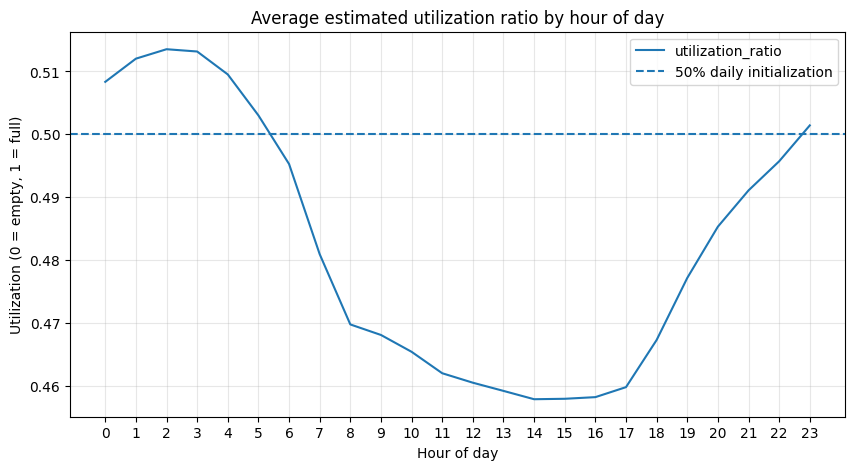

In [19]:
print("Rows with utilization proxy:", feature_df["utilization_ratio"].notna().mean())

plot_df = feature_df.loc[feature_df["utilization_ratio"].notna()].copy()
plot_df["hour_of_day"] = plot_df["hour"].dt.hour

hourly_util = (
    plot_df.groupby("hour_of_day", observed=True)["utilization_ratio"]
    .mean()
    .reset_index()
)

display(hourly_util)

plt.figure(figsize=(10, 5))
plt.plot(hourly_util["hour_of_day"], hourly_util["utilization_ratio"], label="utilization_ratio")
plt.axhline(0.5, linestyle="--", label="50% daily initialization")
plt.title("Average estimated utilization ratio by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Utilization (0 = empty, 1 = full)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Station clustering and weather PCA

- **K-Means** groups stations by activity profile, geography, and capacity.
- **PCA** compresses correlated weather columns; a scree plot justifies the number of components.
- The availability proxy is already in `feature_df`, so downstream models can learn both flow and fullness patterns.


In [20]:
def add_station_clusters(df, n_clusters=8, random_state=42):
    if "station_key" not in df.columns:
        raise ValueError("station_key column is required for station clustering.")

    agg_candidates = [
        "departures",
        "arrivals",
        "net_flow",
        "total_activity",
        "is_commute_peak",
        "is_weekend",
        "capacity",
    ]
    agg_source_cols = ["station_key"] + [c for c in agg_candidates if c in df.columns]
    agg_source = df.loc[:, agg_source_cols]

    agg_dict = {}
    for col in ["departures", "arrivals", "net_flow", "total_activity"]:
        if col in agg_source.columns:
            agg_dict[col] = ["mean", "std"]
    for col in ["is_commute_peak", "is_weekend"]:
        if col in agg_source.columns:
            agg_dict[col] = ["mean"]

    station_profile = (
        agg_source
        .groupby("station_key", observed=True, sort=False)
        .agg(agg_dict)
    )
    station_profile.columns = ["_".join(col).strip("_") for col in station_profile.columns]
    station_profile = station_profile.reset_index()

    optional_numeric = [c for c in ["lat", "lng"] if c in df.columns]
    if optional_numeric:
        geo = (
            df.groupby("station_key", observed=True, sort=False)[optional_numeric]
            .first()
            .reset_index()
        )
        station_profile = station_profile.merge(geo, on="station_key", how="left")

    feature_cols = [c for c in station_profile.columns if c != "station_key"]
    if not feature_cols:
        station_profile["station_cluster"] = 0
        result = df.copy(deep=False)
        result["station_cluster"] = 0
        result["station_cluster"] = result["station_cluster"].astype("category")
        return result, station_profile, None

    X = station_profile[feature_cols].apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median(numeric_only=True)).fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32, copy=False)

    effective_clusters = max(1, min(n_clusters, len(station_profile)))
    if effective_clusters < n_clusters:
        print(
            f"Reducing station clusters from {n_clusters} to {effective_clusters} because there are not enough stations."
        )

    if USE_GPU_CLUSTERING and GPU_CONTEXT["enabled"]:
        cp = GPU_CONTEXT["cp"]
        km = GPU_CONTEXT["GPUKMeans"](n_clusters=effective_clusters, random_state=random_state, n_init=10)
        labels = km.fit_predict(cp.asarray(X_scaled))
        labels = cp.asnumpy(labels).astype("int16")
    else:
        km = SKKMeans(n_clusters=effective_clusters, random_state=random_state, n_init=10)
        labels = km.fit_predict(X_scaled).astype("int16")

    station_profile["station_cluster"] = labels

    cluster_map = station_profile.set_index("station_key")["station_cluster"]
    result = df.copy(deep=False)
    result["station_cluster"] = result["station_key"].map(cluster_map)
    result["station_cluster"] = result["station_cluster"].astype("category")
    return result, station_profile, km


station_profile = None
station_kmeans = None
if USE_STATION_CLUSTERING:
    feature_df, station_profile, station_kmeans = add_station_clusters(
        feature_df,
        n_clusters=N_STATION_CLUSTERS,
        random_state=RANDOM_STATE,
    )

print(feature_df.shape)
display(feature_df[[c for c in ["station_key", "station_cluster"] if c in feature_df.columns]].head())


(11966828, 94)


,station_key,station_cluster
0,1234.56,2
1,1234.56,2
2,1234.56,2
3,1234.56,2
4,1234.56,2


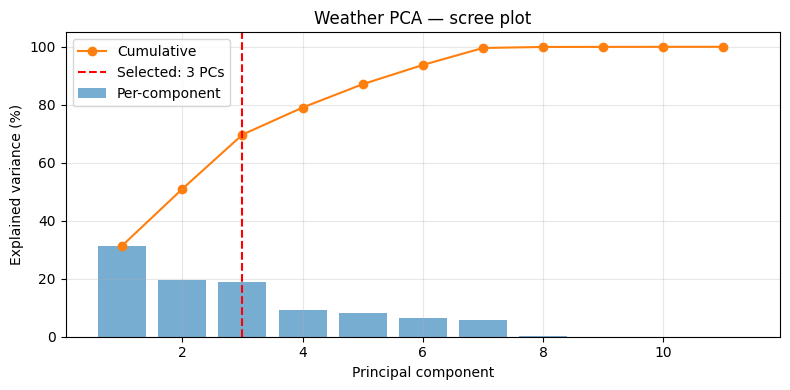

Weather PCA columns: ['weather_pc_1', 'weather_pc_2', 'weather_pc_3']
Explained variance ratio: [0.314 0.195 0.188]


In [21]:
def _to_numpy_host(x):
    cp = GPU_CONTEXT.get("cp", None)

    if cp is not None:
        try:
            return cp.asnumpy(x)
        except Exception:
            pass

    if hasattr(x, "get"):
        try:
            return x.get()
        except Exception:
            pass

    return np.asarray(x)


def add_weather_pca(df, n_components=3):
    weather_cols = [
        c for c in [
            "temperature_f",
            "precipitation_in",
            "rain_in",
            "snowfall_in",
            "snow_depth_ft",
            "wind_speed_mph",
            "relative_humidity_pct",
            "dew_point_f",
            "apparent_temperature_f",
            "wind_gusts_mph",
            "wind_direction_deg",
            "cloud_cover_pct",
            "surface_pressure_hpa",
            "visibility_ft",
        ]
        if c in df.columns
    ]

    if len(weather_cols) < 2:
        print("Not enough weather columns for PCA. Skipping PCA.")
        return df, None, weather_cols

    weather_hourly = (
        df[["hour"] + weather_cols]
        .drop_duplicates(subset=["hour"])
        .sort_values("hour")
        .reset_index(drop=True)
    )

    X = weather_hourly[weather_cols].copy()
    X = X.fillna(X.median(numeric_only=True))

    max_components = min(n_components, X.shape[0], X.shape[1])
    if max_components < 1:
        print("Not enough usable rows/columns for PCA. Skipping PCA.")
        return df, None, weather_cols

    use_gpu_pca = (
        USE_GPU_WEATHER_PCA
        and GPU_CONTEXT.get("enabled", False)
        and GPU_CONTEXT.get("GPUPCA") is not None
        and GPU_CONTEXT.get("cp") is not None
    )

    explained = None
    pca = None

    if use_gpu_pca:
        cp = GPU_CONTEXT["cp"]
        gpu_scaler_cls = GPU_CONTEXT.get("GPUStandardScaler", None)

        X_np = X.to_numpy(dtype=np.float32, copy=False)

        if gpu_scaler_cls is not None:
            X_gpu = cp.asarray(X_np)
            scaler = gpu_scaler_cls()
            X_scaled = scaler.fit_transform(X_gpu)
        else:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_np).astype(np.float32, copy=False)
            X_scaled = cp.asarray(X_scaled)

        full_pca = GPU_CONTEXT["GPUPCA"]()
        full_pca.fit(X_scaled)
        explained = _to_numpy_host(full_pca.explained_variance_ratio_)

        pca = GPU_CONTEXT["GPUPCA"](n_components=max_components)
        pcs = pca.fit_transform(X_scaled)
        pcs = _to_numpy_host(pcs)

    else:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X).astype(np.float32, copy=False)

        full_pca = SKPCA()
        full_pca.fit(X_scaled)
        explained = np.asarray(full_pca.explained_variance_ratio_)

        pca = SKPCA(n_components=max_components, random_state=RANDOM_STATE)
        pcs = pca.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(8, 4))
    cumvar = np.cumsum(explained) * 100
    ax.bar(range(1, len(cumvar) + 1), explained * 100, alpha=0.6, label="Per-component")
    ax.plot(range(1, len(cumvar) + 1), cumvar, marker="o", color="tab:orange", label="Cumulative")
    ax.axvline(max_components, color="red", linestyle="--", label=f"Selected: {max_components} PCs")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Explained variance (%)")
    ax.set_title("Weather PCA — scree plot")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    pc_cols = [f"weather_pc_{i+1}" for i in range(pcs.shape[1])]
    pc_df = pd.DataFrame(pcs, columns=pc_cols)
    pc_df["hour"] = weather_hourly["hour"].to_numpy()

    out = df.merge(pc_df, on="hour", how="left")
    return out, pca, weather_cols


weather_pca = None
weather_pca_cols = []
if USE_WEATHER_PCA:
    feature_df, weather_pca, weather_pca_cols = add_weather_pca(
        feature_df,
        n_components=N_WEATHER_PCS,
    )

model_base_cache = OUTPUT_DIR / "feature_df_model_ready_2025_v7_final.parquet"
save_table_with_fallback(feature_df, model_base_cache)

pca_cols_present = [c for c in feature_df.columns if c.startswith("weather_pc_")]
print("Weather PCA columns:", pca_cols_present)
if weather_pca is not None:
    print(
        "Explained variance ratio:",
        np.round(_to_numpy_host(weather_pca.explained_variance_ratio_), 3),
    )

## Exploratory analysis

Plots: hourly demand, weekday vs weekend, precipitation impact, monthly seasonality, busiest stations, and capacity-aware utilization.


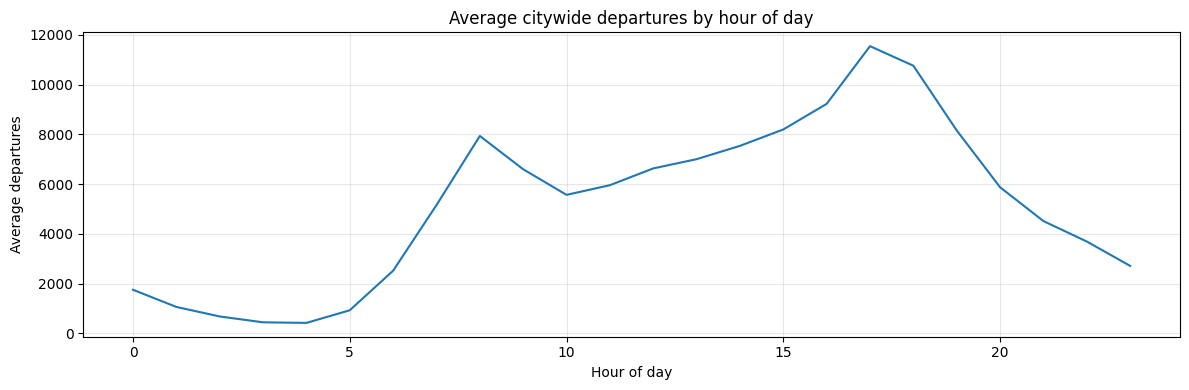

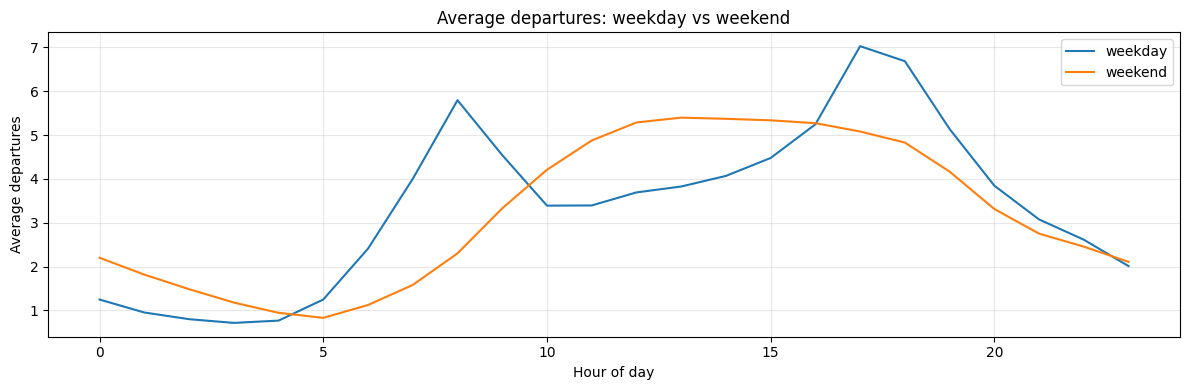

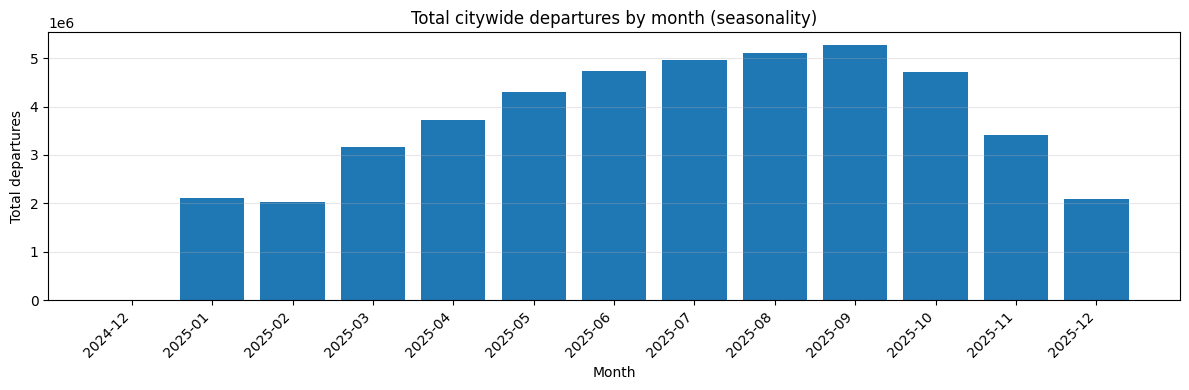

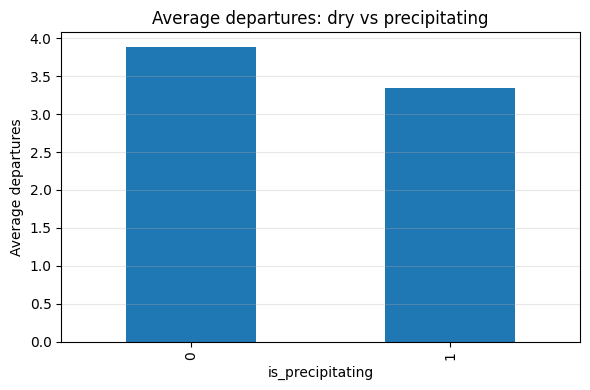

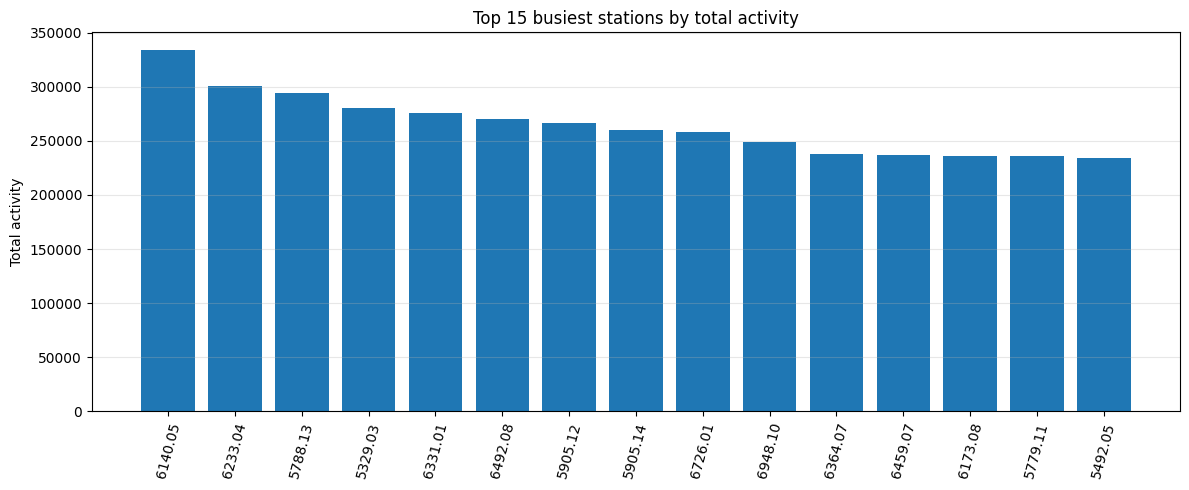

In [22]:
city_hour = (
    feature_df.groupby("hour", as_index=False)[["departures", "arrivals", "net_flow", "total_activity"]]
    .sum()
    .sort_values("hour")
)

# 1) Average citywide departures by hour of day
plt.figure(figsize=(12, 4))
city_hour.groupby(city_hour["hour"].dt.hour)["departures"].mean().plot()
plt.title("Average citywide departures by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Average departures")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Weekday vs weekend
weekday_weekend = (
    feature_df.groupby(["hour_of_day", "is_weekend"], as_index=False)["departures"]
    .mean()
    .pivot(index="hour_of_day", columns="is_weekend", values="departures")
)
weekday_weekend.columns = ["weekday" if c == 0 else "weekend" for c in weekday_weekend.columns]
weekday_weekend.plot(figsize=(12, 4))
plt.title("Average departures: weekday vs weekend")
plt.xlabel("Hour of day")
plt.ylabel("Average departures")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Monthly seasonality — total departures by month
monthly = (
    feature_df.assign(month_label=feature_df["hour"].dt.to_period("M").astype(str))
    .groupby("month_label", as_index=False)["departures"]
    .sum()
    .sort_values("month_label")
)
plt.figure(figsize=(12, 4))
plt.bar(monthly["month_label"], monthly["departures"])
plt.title("Total citywide departures by month (seasonality)")
plt.xlabel("Month")
plt.ylabel("Total departures")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Precipitation impact
if "is_precipitating" in feature_df.columns:
    rain_compare = feature_df.groupby("is_precipitating")["departures"].mean()
    plt.figure(figsize=(6, 4))
    rain_compare.plot(kind="bar")
    plt.title("Average departures: dry vs precipitating")
    plt.xlabel("is_precipitating")
    plt.ylabel("Average departures")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# 5) Busiest stations
busiest = (
    feature_df.groupby("station_key", as_index=False)["total_activity"]
    .sum()
    .sort_values("total_activity", ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 5))
plt.bar(busiest["station_key"].astype(str), busiest["total_activity"])
plt.title("Top 15 busiest stations by total activity")
plt.xticks(rotation=75)
plt.ylabel("Total activity")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Modeling helpers

This section keeps the validation/test discipline from v6 and adds the capacity fix:

- model selection happens on **validation**,
- the **test set is untouched** until the end,
- the default **primary target is next-hour utilization ratio**,
- availability-style predictions are clipped to their valid ranges,
- the best validation model for each target is retrained on **train + validation** before final test evaluation.


In [23]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return {
        "rmse": rmse,
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def chronological_split(model_df):
    model_df = model_df.sort_values("hour").reset_index(drop=True)
    unique_hours = np.sort(model_df["hour"].unique())
    if len(unique_hours) < 10:
        raise ValueError("Not enough hourly periods for a 70/15/15 chronological split.")

    train_idx = max(1, int(len(unique_hours) * 0.70))
    valid_idx = max(train_idx + 1, int(len(unique_hours) * 0.85))
    valid_idx = min(valid_idx, len(unique_hours) - 1)

    train_cutoff = unique_hours[train_idx]
    valid_cutoff = unique_hours[valid_idx]

    train_df = model_df.loc[model_df["hour"] < train_cutoff].copy()
    valid_df = model_df.loc[(model_df["hour"] >= train_cutoff) & (model_df["hour"] < valid_cutoff)].copy()
    test_df = model_df.loc[model_df["hour"] >= valid_cutoff].copy()
    return train_df, valid_df, test_df


def get_feature_columns(model_df, target_col):
    ordered_candidates = [
        "station_key",
        "station_cluster",
        "lat",
        "lng",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
        "hour_of_day",
        "day_of_week",
        "month",
        "is_weekend",
        "is_holiday",
        "is_rush_hour",
        "is_commute_peak",
        "is_overnight",
        "is_precipitating",
        "is_raining",
        "is_snowing",
        "heavy_precip_flag",
        "departures_lag_1",
        "departures_lag_2",
        "departures_lag_24",
        "arrivals_lag_1",
        "arrivals_lag_2",
        "arrivals_lag_24",
        "net_flow_lag_1",
        "net_flow_lag_2",
        "net_flow_lag_24",
        "total_activity_lag_1",
        "total_activity_lag_2",
        "total_activity_lag_24",
        "departures_roll_3",
        "departures_roll_24",
        "arrivals_roll_3",
        "arrivals_roll_24",
        "net_flow_roll_3",
        "net_flow_roll_24",
        "total_activity_roll_3",
        "total_activity_roll_24",
        "capacity",
        "capacity_known",
        "capacity_imputed",
        "is_active_station",
        "estimated_bikes_lag_1",
        "estimated_bikes_lag_2",
        "estimated_bikes_lag_24",
        "estimated_bikes_roll_3",
        "estimated_bikes_roll_24",
        "available_docks_lag_1",
        "available_docks_lag_2",
        "available_docks_lag_24",
        "available_docks_roll_3",
        "available_docks_roll_24",
        "utilization_ratio_lag_1",
        "utilization_ratio_lag_2",
        "utilization_ratio_lag_24",
        "utilization_ratio_roll_3",
        "utilization_ratio_roll_24",
        "is_nearly_empty",
        "is_nearly_full",
    ]

    ordered_candidates.extend([c for c in model_df.columns if c.startswith("weather_pc_")])
    feature_cols = [c for c in ordered_candidates if c in model_df.columns and c not in ["hour", target_col]]
    return list(dict.fromkeys(feature_cols))


def build_model_frame(df, target_col, top_n_stations=100):
    if target_col not in df.columns:
        raise ValueError(f"Target column not found: {target_col}")

    if "station_key" not in df.columns or "total_activity" not in df.columns:
        raise ValueError("Expected station_key and total_activity columns in feature_df.")

    busy_stations = (
        df.groupby("station_key", observed=True)["total_activity"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n_stations)
        .index
    )

    feature_cols = get_feature_columns(df, target_col)
    keep_cols = ["hour", target_col] + feature_cols
    keep_cols = [c for c in keep_cols if c in df.columns]

    mask = df["station_key"].isin(busy_stations) & df[target_col].notna()
    model_df = df.loc[mask, keep_cols].copy()

    for cat_col in ["station_key", "station_cluster"]:
        if cat_col in model_df.columns:
            model_df[cat_col] = model_df[cat_col].astype("category")

    return model_df


class DenseTabularPreprocessor:
    def __init__(self, numeric_features, categorical_features):
        self.numeric_features = list(numeric_features)
        self.categorical_features = list(categorical_features)
        self.num_imputer = SimpleImputer(strategy="median") if self.numeric_features else None
        self.cat_imputer = SimpleImputer(strategy="most_frequent") if self.categorical_features else None
        self.onehot = make_dense_onehot_encoder() if self.categorical_features else None
        self.feature_names_out_ = None

    def fit(self, X):
        feature_names = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors="coerce")
            self.num_imputer.fit(num_df)
            feature_names.extend(self.numeric_features)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype("string")
            cat_filled = self.cat_imputer.fit_transform(cat_df)
            self.onehot.fit(cat_filled)
            feature_names.extend(self.onehot.get_feature_names_out(self.categorical_features).tolist())

        self.feature_names_out_ = np.asarray(feature_names, dtype=object)
        return self

    def transform(self, X):
        parts = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors="coerce")
            num_arr = self.num_imputer.transform(num_df).astype(GPU_NUMERIC_DTYPE, copy=False)
            parts.append(num_arr)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype("string")
            cat_filled = self.cat_imputer.transform(cat_df)
            cat_arr = self.onehot.transform(cat_filled).astype(GPU_NUMERIC_DTYPE, copy=False)
            parts.append(cat_arr)

        if not parts:
            return np.empty((len(X), 0), dtype=GPU_NUMERIC_DTYPE)

        return np.concatenate(parts, axis=1).astype(GPU_NUMERIC_DTYPE, copy=False)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def get_feature_names_out(self):
        return self.feature_names_out_


class DenseGPUReadyRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, model_name, numeric_features, categorical_features, random_state=42, prefer_gpu=True):
        self.model_name = model_name
        self.numeric_features = list(numeric_features)
        self.categorical_features = list(categorical_features)
        self.random_state = random_state
        self.prefer_gpu = prefer_gpu

    def _use_gpu(self):
        return bool(self.prefer_gpu and USE_GPU_MODELS and GPU_CONTEXT["enabled"])

    def _build_cpu_model(self):
        if self.model_name == "Linear Regression":
            return SKLinearRegression()
        if self.model_name == "Random Forest":
            return SKRandomForestRegressor(
                n_estimators=150,
                max_depth=12,
                min_samples_leaf=10,
                random_state=self.random_state,
                n_jobs=-1,
            )
        if self.model_name == "Random Forest (deeper)":
            return SKRandomForestRegressor(
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=5,
                random_state=self.random_state,
                n_jobs=-1,
            )
        raise ValueError(f"Unknown model name: {self.model_name}")

    def _build_gpu_model(self):
        if self.model_name == "Linear Regression":
            return GPU_CONTEXT["GPULinearRegression"]()
        if self.model_name == "Random Forest":
            return GPU_CONTEXT["GPURandomForestRegressor"](
                n_estimators=150,
                max_depth=12,
                min_samples_leaf=10,
                random_state=self.random_state,
            )
        if self.model_name == "Random Forest (deeper)":
            return GPU_CONTEXT["GPURandomForestRegressor"](
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=5,
                random_state=self.random_state,
            )
        raise ValueError(f"Unknown model name: {self.model_name}")

    def fit(self, X, y):
        self.preprocess_ = DenseTabularPreprocessor(self.numeric_features, self.categorical_features)
        X_dense = self.preprocess_.fit_transform(X)
        y_np = np.asarray(y, dtype=GPU_NUMERIC_DTYPE).reshape(-1)

        self.use_gpu_ = self._use_gpu()
        if self.use_gpu_:
            cp = GPU_CONTEXT["cp"]
            self.model_ = self._build_gpu_model()
            self.model_.fit(cp.asarray(X_dense), cp.asarray(y_np))
        else:
            self.model_ = self._build_cpu_model()
            self.model_.fit(X_dense, y_np)
        return self

    def predict(self, X):
        X_dense = self.preprocess_.transform(X)
        if self.use_gpu_:
            cp = GPU_CONTEXT["cp"]
            preds = self.model_.predict(cp.asarray(X_dense))
            return cp.asnumpy(preds).reshape(-1)
        return np.asarray(self.model_.predict(X_dense)).reshape(-1)

    def get_feature_names_out(self):
        return self.preprocess_.get_feature_names_out()

    def get_feature_importance_frame(self):
        if not hasattr(self.model_, "feature_importances_"):
            return None
        importances = np.asarray(self.model_.feature_importances_).reshape(-1)
        feature_names = self.get_feature_names_out()
        return pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
        }).sort_values("importance", ascending=False).reset_index(drop=True)


def build_estimator(model_name, numeric_features, categorical_features, random_state=42):
    return DenseGPUReadyRegressor(
        model_name=model_name,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        random_state=random_state,
        prefer_gpu=True,
    )


def constrain_predictions(preds, df, target_col):
    preds = np.asarray(preds, dtype=np.float32).reshape(-1)

    if target_col == "utilization_ratio_next_hour":
        return np.clip(preds, 0.0, 1.0)

    if target_col in {"estimated_bikes_next_hour", "available_docks_next_hour"} and "capacity" in df.columns:
        upper = pd.to_numeric(df["capacity"], errors="coerce").fillna(0).to_numpy(dtype=np.float32)
        return np.clip(preds, 0.0, upper)

    return preds


def naive_predict(df, target_col, fallback_mean):
    lag_map = {
        "departures_next_hour": "departures_lag_1",
        "arrivals_next_hour": "arrivals_lag_1",
        "net_flow_next_hour": "net_flow_lag_1",
        "estimated_bikes_next_hour": "estimated_bikes_lag_1",
        "available_docks_next_hour": "available_docks_lag_1",
        "utilization_ratio_next_hour": "utilization_ratio_lag_1",
    }
    lag_col = lag_map.get(target_col)
    if lag_col and lag_col in df.columns:
        preds = df[lag_col].fillna(fallback_mean).to_numpy()
    else:
        preds = np.repeat(fallback_mean, len(df))
    return constrain_predictions(preds, df, target_col)


def run_target_experiment(df, target_col, primary_label=False):
    model_df = build_model_frame(df, target_col, top_n_stations=TOP_N_STATIONS_FOR_MODEL)
    train_df, valid_df, test_df = chronological_split(model_df)

    feature_cols = [c for c in model_df.columns if c not in ["hour", target_col]]
    categorical_features = [c for c in ["station_key", "station_cluster"] if c in feature_cols]
    numeric_features = [c for c in feature_cols if c not in categorical_features]

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target_col]
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    train_valid_df = pd.concat([train_df, valid_df], ignore_index=True)
    X_train_valid = train_valid_df[feature_cols]
    y_train_valid = train_valid_df[target_col]

    model_names = ["Naive baseline", "Linear Regression", "Random Forest", "Random Forest (deeper)"]

    validation_rows = []
    test_rows = []
    final_models = {}
    test_predictions = {}

    train_mean = float(y_train.mean())
    train_valid_mean = float(y_train_valid.mean())

    for model_name in model_names:
        if model_name == "Naive baseline":
            valid_pred = naive_predict(valid_df, target_col, fallback_mean=train_mean)
            test_pred = naive_predict(test_df, target_col, fallback_mean=train_valid_mean)
        else:
            estimator_valid = build_estimator(model_name, numeric_features, categorical_features, random_state=RANDOM_STATE)
            estimator_valid.fit(X_train, y_train)
            valid_pred = constrain_predictions(estimator_valid.predict(X_valid), valid_df, target_col)
            del estimator_valid

            fitted_model = build_estimator(model_name, numeric_features, categorical_features, random_state=RANDOM_STATE)
            fitted_model.fit(X_train_valid, y_train_valid)
            test_pred = constrain_predictions(fitted_model.predict(X_test), test_df, target_col)
            final_models[model_name] = fitted_model

        valid_metrics = regression_metrics(y_valid, valid_pred)
        valid_metrics.update({"target": target_col, "model": model_name, "split": "validation"})
        validation_rows.append(valid_metrics)

        test_metrics = regression_metrics(y_test, test_pred)
        test_metrics.update({"target": target_col, "model": model_name, "split": "test"})
        test_rows.append(test_metrics)

        test_predictions[model_name] = np.asarray(test_pred)

    validation_results = pd.DataFrame(validation_rows).sort_values("rmse").reset_index(drop=True)
    test_results = pd.DataFrame(test_rows).sort_values("rmse").reset_index(drop=True)
    best_model_name = validation_results.iloc[0]["model"]

    comparison = test_df[["hour", "station_key", target_col]].copy()
    for model_name, preds in test_predictions.items():
        safe_name = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
        comparison[f"pred_{safe_name}"] = preds

    test_meta_cols = [
        c for c in [
            "hour",
            "station_key",
            "is_precipitating",
            "is_weekend",
            "total_activity_lag_1",
            "capacity",
            "capacity_known",
        ]
        if c in test_df.columns
    ]
    test_meta = test_df[test_meta_cols].copy()

    result = {
        "target": target_col,
        "validation_results": validation_results,
        "test_results": test_results,
        "best_model_name": best_model_name,
        "best_model": final_models.get(best_model_name),
        "comparison": comparison,
        "test_meta": test_meta,
        "feature_cols": feature_cols,
    }

    del model_df, train_df, valid_df, test_df, train_valid_df, X_train, X_valid, X_test, X_train_valid
    del y_train, y_valid, y_test, y_train_valid, test_predictions
    return result

def _extract_model_and_feature_names(fitted_pipeline):
    model = None
    feature_names = None

    if fitted_pipeline is None:
        return None, None

    if hasattr(fitted_pipeline, "named_steps"):
        model = fitted_pipeline.named_steps.get("model", None)
        preprocessor = fitted_pipeline.named_steps.get("preprocess", None)
        if preprocessor is not None and hasattr(preprocessor, "get_feature_names_out"):
            feature_names = np.asarray(preprocessor.get_feature_names_out(), dtype=object)

    else:
        if hasattr(fitted_pipeline, "model_"):
            model = fitted_pipeline.model_
        else:
            model = fitted_pipeline

        if hasattr(fitted_pipeline, "get_feature_names_out"):
            try:
                feature_names = np.asarray(fitted_pipeline.get_feature_names_out(), dtype=object)
            except Exception:
                pass

        if feature_names is None and hasattr(fitted_pipeline, "preprocess_"):
            pre = fitted_pipeline.preprocess_
            if hasattr(pre, "get_feature_names_out"):
                try:
                    feature_names = np.asarray(pre.get_feature_names_out(), dtype=object)
                except Exception:
                    pass

    return model, feature_names

def extract_feature_importance(fitted_pipeline):
    model, feature_names = _extract_model_and_feature_names(fitted_pipeline)

    if model is None or not hasattr(model, "feature_importances_"):
        return None

    raw_importances = None

    try:
        import cuml
        with cuml.using_output_type("numpy"):
            raw_importances = model.feature_importances_
    except Exception:
        raw_importances = model.feature_importances_

    importances = _to_numpy_host(raw_importances).reshape(-1)

    if feature_names is None:
        feature_names = np.asarray(
            [f"feature_{i}" for i in range(len(importances))],
            dtype=object,
        )

    if len(feature_names) != len(importances):
        min_len = min(len(feature_names), len(importances))
        print(
            f"Feature-importance length mismatch: "
            f"{len(feature_names)} names vs {len(importances)} importances. "
            f"Using first {min_len} entries."
        )
        feature_names = feature_names[:min_len]
        importances = importances[:min_len]

    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

def _patched_get_feature_importance_frame(self):
    return extract_feature_importance(self)

DenseGPUReadyRegressor.get_feature_importance_frame = _patched_get_feature_importance_frame


In [24]:

all_target_results = {}
summary_rows = []
primary_result = None

for target_col in TARGETS:
    result = run_target_experiment(feature_df, target_col, primary_label=(target_col == PRIMARY_TARGET))

    best_valid = result["validation_results"].iloc[0]
    best_test = result["test_results"].set_index("model").loc[best_valid["model"]]

    summary_rows.append({
        "target": target_col,
        "best_validation_model": best_valid["model"],
        "validation_rmse": best_valid["rmse"],
        "validation_mae": best_valid["mae"],
        "validation_r2": best_valid["r2"],
        "final_test_rmse": best_test["rmse"],
        "final_test_mae": best_test["mae"],
        "final_test_r2": best_test["r2"],
    })

    if target_col == PRIMARY_TARGET:
        primary_result = result
    else:
        all_target_results[target_col] = {
            "validation_results": result["validation_results"],
            "test_results": result["test_results"],
            "best_model_name": result["best_model_name"],
        }
        del result

if primary_result is not None:
    all_target_results[PRIMARY_TARGET] = primary_result

target_summary = pd.DataFrame(summary_rows).sort_values(["final_test_r2", "validation_r2"], ascending=False)
display(target_summary)


,target,best_validation_model,validation_rmse,validation_mae,validation_r2,final_test_rmse,final_test_mae,final_test_r2
0,utilization_ratio_next_hour,Random Forest (deeper),0.112013,0.074766,0.850207,0.096278,0.066015,0.846928
1,departures_next_hour,Random Forest (deeper),5.887496,4.038321,0.784847,4.628021,3.288031,0.647971
2,arrivals_next_hour,Random Forest (deeper),6.117496,4.106759,0.775879,4.865003,3.343166,0.631802
3,net_flow_next_hour,Random Forest (deeper),5.810532,3.979764,0.501117,4.472939,3.083920,0.397272


In [25]:
primary_result = all_target_results[PRIMARY_TARGET]
print("Primary target:", PRIMARY_TARGET)
print("Best validation model:", primary_result["best_model_name"])

print()
print("Validation results")
display(primary_result["validation_results"])

print()
print("Test results")
display(primary_result["test_results"])

summary_path = OUTPUT_DIR / "target_summary_v7.csv"
validation_path = OUTPUT_DIR / f"validation_results_{PRIMARY_TARGET}_v7.csv"
test_path = OUTPUT_DIR / f"test_results_{PRIMARY_TARGET}_v7.csv"

target_summary.to_csv(summary_path, index=False)
primary_result["validation_results"].to_csv(validation_path, index=False)
primary_result["test_results"].to_csv(test_path, index=False)

print("Saved:")
print(summary_path)
print(validation_path)
print(test_path)


Primary target: utilization_ratio_next_hour
Best validation model: Random Forest (deeper)

Validation results


,rmse,mae,r2,target,model,split
0,0.112013,0.074766,0.850207,utilization_ratio_next_hour,Random Forest (deeper),validation
1,0.117935,0.078558,0.833948,utilization_ratio_next_hour,Random Forest,validation
2,0.163268,0.110615,0.681756,utilization_ratio_next_hour,Linear Regression,validation
3,0.175648,0.114197,0.631666,utilization_ratio_next_hour,Naive baseline,validation



Test results


,rmse,mae,r2,target,model,split
0,0.096278,0.066015,0.846928,utilization_ratio_next_hour,Random Forest (deeper),test
1,0.101104,0.069033,0.831198,utilization_ratio_next_hour,Random Forest,test
2,0.123659,0.088451,0.747481,utilization_ratio_next_hour,Linear Regression,test
3,0.144952,0.093857,0.653027,utilization_ratio_next_hour,Naive baseline,test


Saved:
outputs/target_summary_v7.csv
outputs/validation_results_utilization_ratio_next_hour_v7.csv
outputs/test_results_utilization_ratio_next_hour_v7.csv


## Report-ready diagnostics for the primary target

Plots:
1. Predictions vs actuals — **two stations** (highest-activity + highest weekend share among active stations).
2. Mean absolute error by hour of day.
3. **Residual histogram** and **Q-Q plot** for the best model.

If `PRIMARY_TARGET = "utilization_ratio_next_hour"`, interpret the y-axis as station fullness from 0 to 1.


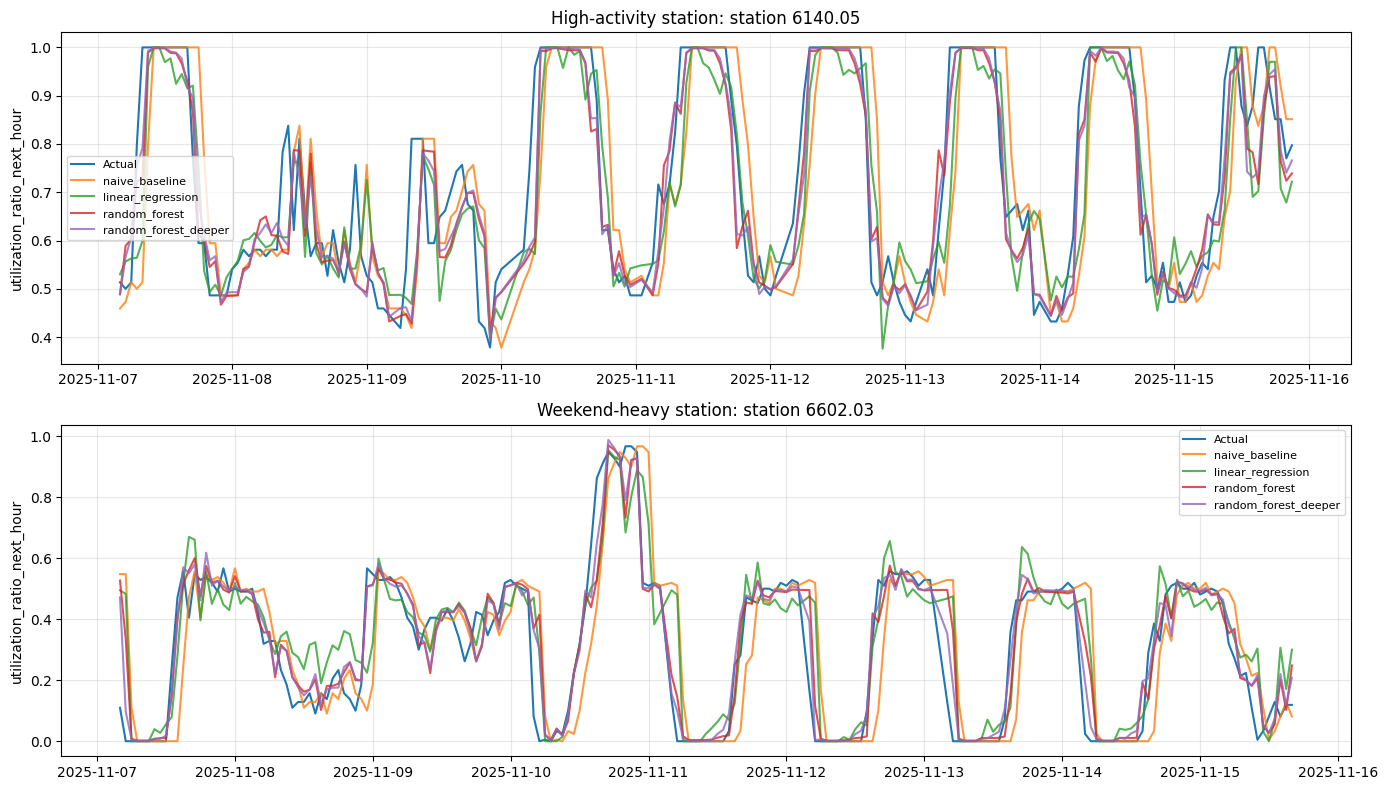

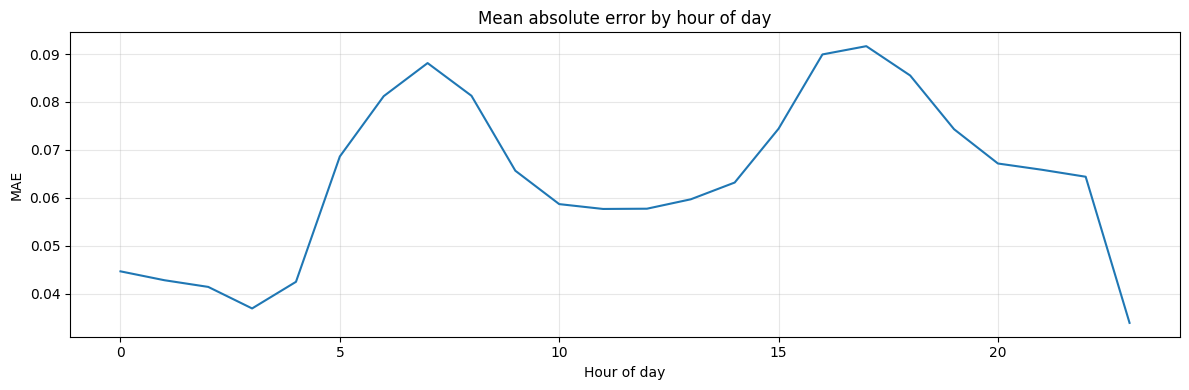

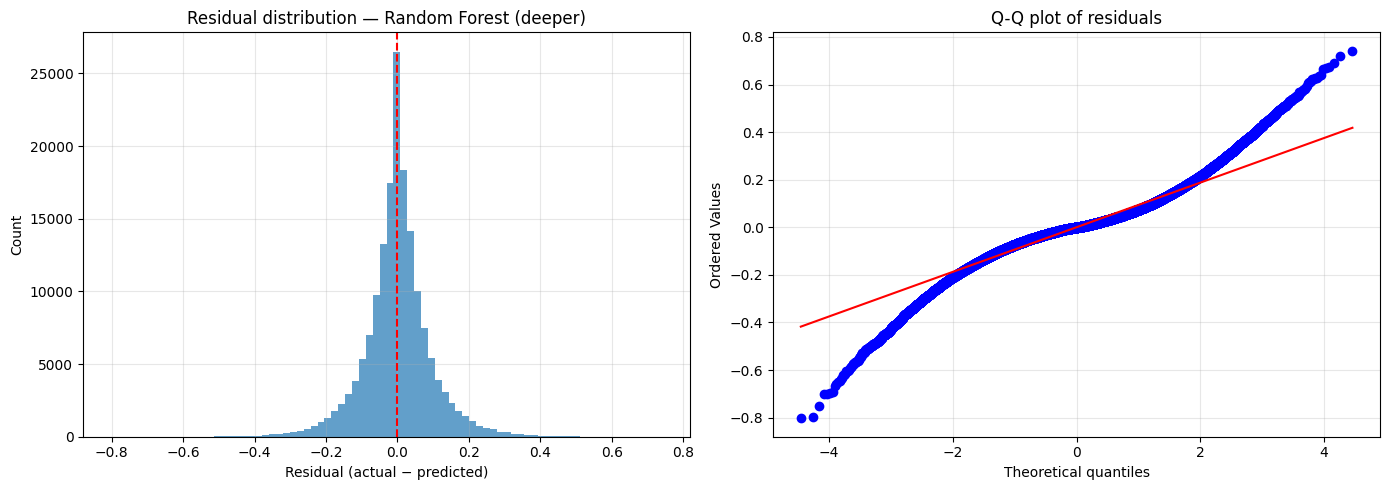

Residual mean: 0.000  |  std: 0.096  |  skew: 0.031


In [26]:
import scipy.stats as stats

comparison = primary_result["comparison"].copy()
best_col = "pred_" + primary_result["best_model_name"].lower().replace(" ", "_").replace("(", "").replace(")", "")

test_meta = primary_result.get("test_meta", pd.DataFrame()).copy()

# --- Identify two representative stations ---
if "total_activity_lag_1" in test_meta.columns:
    station_activity = test_meta.groupby("station_key")["total_activity_lag_1"].sum().sort_values(ascending=False)
else:
    station_activity = comparison.groupby("station_key")[PRIMARY_TARGET].size().sort_values(ascending=False)

commuter_station = station_activity.index[0]

if "is_weekend" in test_meta.columns:
    weekend_share = test_meta.groupby("station_key")["is_weekend"].mean()
    top50 = station_activity.head(min(50, len(station_activity))).index
    leisure_station = weekend_share.loc[weekend_share.index.isin(top50)].idxmax()
else:
    leisure_station = station_activity.index[min(10, len(station_activity) - 1)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, stn, label in zip(axes, [commuter_station, leisure_station], ["High-activity station", "Weekend-heavy station"]):
    plot_df = comparison[comparison["station_key"] == stn].sort_values("hour").head(200)
    ax.plot(plot_df["hour"], plot_df[PRIMARY_TARGET], label="Actual")
    for col in [c for c in comparison.columns if c.startswith("pred_")]:
        ax.plot(plot_df["hour"], plot_df[col], label=col.replace("pred_", ""), alpha=0.8)
    ax.set_title(f"{label}: station {stn}")
    ax.set_ylabel(PRIMARY_TARGET)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- MAE by hour of day ---
error_df = comparison[["hour", PRIMARY_TARGET, best_col]].copy()
error_df["abs_error"] = (error_df[PRIMARY_TARGET] - error_df[best_col]).abs()
error_df["hour_of_day"] = error_df["hour"].dt.hour

hour_error = error_df.groupby("hour_of_day", as_index=False)["abs_error"].mean()
plt.figure(figsize=(12, 4))
plt.plot(hour_error["hour_of_day"], hour_error["abs_error"])
plt.title("Mean absolute error by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Residual distribution: histogram + Q-Q plot ---
residuals = (comparison[PRIMARY_TARGET] - comparison[best_col]).dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(residuals, bins=80, edgecolor="none", alpha=0.7)
ax1.axvline(0, color="red", linestyle="--")
ax1.set_title(f"Residual distribution — {primary_result['best_model_name']}")
ax1.set_xlabel("Residual (actual − predicted)")
ax1.set_ylabel("Count")
ax1.grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title("Q-Q plot of residuals")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.3f}  |  std: {residuals.std():.3f}  |  skew: {residuals.skew():.3f}")


,is_precipitating,abs_error
0,0,0.066667
1,1,0.061593


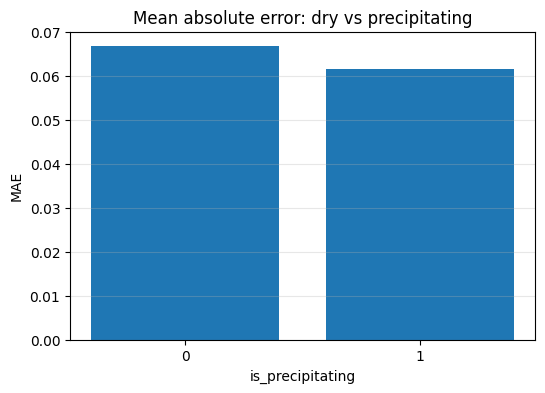

In [27]:

test_meta = primary_result.get("test_meta")
if test_meta is not None and "is_precipitating" in test_meta.columns:
    weather_error = test_meta[["hour", "station_key", "is_precipitating"]].copy().reset_index(drop=True)
    weather_error["abs_error"] = (comparison[PRIMARY_TARGET].reset_index(drop=True) - comparison[best_col].reset_index(drop=True)).abs()

    weather_summary = weather_error.groupby("is_precipitating", as_index=False)["abs_error"].mean()
    display(weather_summary)

    plt.figure(figsize=(6, 4))
    plt.bar(weather_summary["is_precipitating"].astype(str), weather_summary["abs_error"])
    plt.title("Mean absolute error: dry vs precipitating")
    plt.xlabel("is_precipitating")
    plt.ylabel("MAE")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()


,feature,importance
0,utilization_ratio_lag_1,0.507488
1,is_nearly_full,0.183060
2,is_nearly_empty,0.129419
3,hour_cos,0.022508
4,hour_of_day,0.022348
5,utilization_ratio_roll_24,0.015704
6,hour_sin,0.014837
7,net_flow_roll_3,0.010131
8,net_flow_roll_24,0.007186
9,lat,0.005487


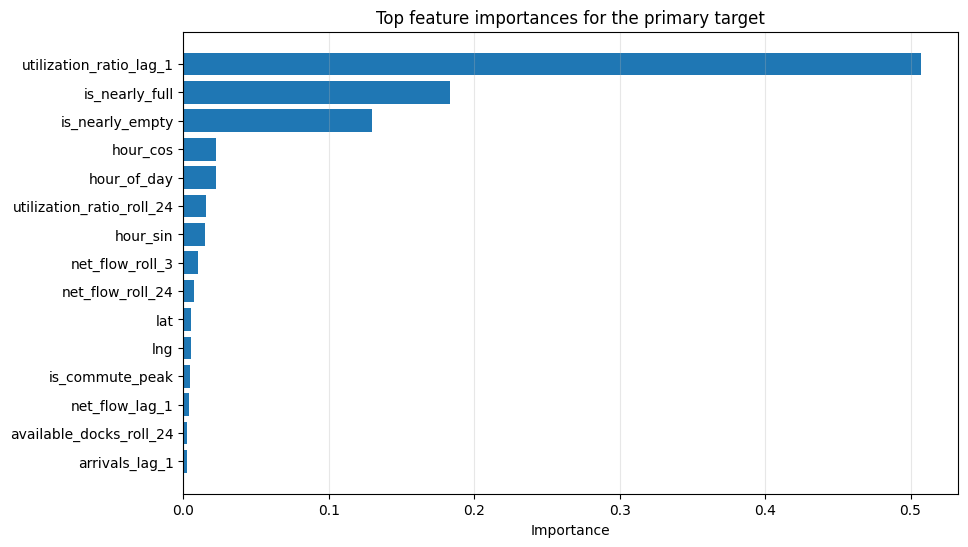

In [28]:
importance_df = extract_feature_importance(primary_result["best_model"])
if importance_df is None:
    print("Feature importance is only available for tree-based models. The selected primary model does not expose feature_importances_.")
else:
    display(importance_df.head(20))

    top_imp = importance_df.head(15).sort_values("importance")
    plt.figure(figsize=(10, 6))
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.title("Top feature importances for the primary target")
    plt.xlabel("Importance")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

    importance_df.to_csv(OUTPUT_DIR / f"feature_importance_{PRIMARY_TARGET}_v7.csv", index=False)


## What to write in the report after running this notebook

Use the outputs from this notebook to support these discussion points:

1. **Availability proxy vs raw flow**
   The notebook now includes a bounded availability-style target: `utilization_ratio_next_hour`.
   This lines up better with the original problem statement than predicting raw departures alone.

2. **Capacity data limitations**
   Capacity came from the live GBFS feed, not a historical archive. Mention that station capacity may
   have changed during 2025, so the proxy is approximate even when the model performs well.

3. **Proxy construction assumptions**
   Explain the 50%-of-capacity daily initialization and the cumulative net-flow update.
   That assumption is simple, transparent, and easy to discuss in a class report.

4. **Validation vs test discipline**
   Model selection used validation only. The test set was evaluated exactly once.

5. **Why bounded targets help**
   Utilization is clipped to `[0, 1]`, which prevents impossible predictions and makes interpretation easier:
   values near 0 imply likely bike scarcity; values near 1 imply the station is close to full.

6. **Station clustering and context features**
   K-Means uses demand profile, geography, and capacity, which helps separate commuter hubs from smaller neighborhood stations.

7. **What to improve next**
   If you want a stronger availability estimate later, replace the 50% daily initialization with a real GBFS station-status history
   or a learned initial-state estimate per station and hour.
